##데이터셋 수집


In [ ]:
!git clone https://github.com/poori-nuna/HOD-Benchmark-Dataset.git


Cloning into 'HOD-Benchmark-Dataset'...
remote: Enumerating objects: 31937, done.
remote: Counting objects: 100% (227/227), done.
remote: Compressing objects: 100% (202/202), done.
remote: Total 31937 (delta 49), reused 150 (delta 19), pack-reused 31710 (from 1)
Receiving objects: 100% (31937/31937), 567.35 MiB | 31.12 MiB/s, done.
Resolving deltas: 100% (10562/10562), done.
Updating files: 100% (63801/63801), done.


In [ ]:
import os
import shutil
import random
from glob import glob

BASE_DIR = "HOD-Benchmark-Dataset/dataset/class"
TARGET_BASE = "/content/drive/MyDrive/blurit_dataset_yolo"
SPLIT_RATIO = [0.8, 0.1, 0.1]  # train:val:test

case_types = ["normal_cases", "hard_cases"]

for class_name in os.listdir(BASE_DIR):
    class_path = os.path.join(BASE_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    for case_type in case_types:
        case_name = "normal" if case_type == "normal_cases" else "hard"
        jpg_dir = os.path.join(class_path, case_type, "jpg")
        txt_dir = os.path.join(class_path, case_type, "txt")

        if not os.path.exists(jpg_dir) or not os.path.exists(txt_dir):
            continue

        # 대상 폴더 생성
        for split in ['train', 'val', 'test']:
            os.makedirs(os.path.join(TARGET_BASE, class_name, case_name, "images", split), exist_ok=True)
            os.makedirs(os.path.join(TARGET_BASE, class_name, case_name, "labels", split), exist_ok=True)

        # 이미지-라벨 쌍 수집
        image_label_pairs = []
        for img_path in glob(os.path.join(jpg_dir, "*.jpg")):
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            label_path = os.path.join(txt_dir, base_name + ".txt")
            if os.path.exists(label_path):
                image_label_pairs.append((img_path, label_path))

        # 셔플 및 분할
        random.shuffle(image_label_pairs)
        n_total = len(image_label_pairs)
        n_train = int(n_total * SPLIT_RATIO[0])
        n_val = int(n_total * SPLIT_RATIO[1])

        splits = {
            'train': image_label_pairs[:n_train],
            'val': image_label_pairs[n_train:n_train + n_val],
            'test': image_label_pairs[n_train + n_val:]
        }

        # 복사
        for split in ['train', 'val', 'test']:
            for img_path, label_path in splits[split]:
                img_dest = os.path.join(TARGET_BASE, class_name, case_name, "images", split, os.path.basename(img_path))
                label_dest = os.path.join(TARGET_BASE, class_name, case_name, "labels", split, os.path.basename(label_path))
                shutil.copy(img_path, img_dest)
                shutil.copy(label_path, label_dest)

        print(f"✅ 클래스 '{class_name}' / 케이스 '{case_name}' 변환 완료 ({len(image_label_pairs)}개)")


✅ 클래스 'gun' / 케이스 'normal' 변환 완료 (999개)
✅ 클래스 'gun' / 케이스 'hard' 변환 완료 (566개)
✅ 클래스 'alcohol' / 케이스 'normal' 변환 완료 (533개)
✅ 클래스 'alcohol' / 케이스 'hard' 변환 완료 (978개)
✅ 클래스 'knife' / 케이스 'normal' 변환 완료 (2366개)
✅ 클래스 'knife' / 케이스 'hard' 변환 완료 (820개)
✅ 클래스 'insulting_gesture' / 케이스 'normal' 변환 완료 (466개)
✅ 클래스 'insulting_gesture' / 케이스 'hard' 변환 완료 (267개)
✅ 클래스 'cigarette' / 케이스 'normal' 변환 완료 (550개)
✅ 클래스 'cigarette' / 케이스 'hard' 변환 완료 (1538개)
✅ 클래스 'blood' / 케이스 'normal' 변환 완료 (554개)
✅ 클래스 'blood' / 케이스 'hard' 변환 완료 (994개)


In [ ]:
import os
import shutil
from glob import glob

BASE = "/content/drive/MyDrive/blurit_dataset_yolo"
class_names = ['alcohol', 'blood', 'cigarette', 'gun', 'insulting_gesture', 'knife']
modes = ['normal', 'hard', 'all']

def prepare_dir(base_path):
    for split in ['train', 'val']:
        os.makedirs(os.path.join(base_path, "images", split), exist_ok=True)
        os.makedirs(os.path.join(base_path, "labels", split), exist_ok=True)

def copy_data(src_img_dir, src_lbl_dir, target_img_dir, target_lbl_dir):
    for image_path in glob(os.path.join(src_img_dir, "*.jpg")):
        shutil.copy(image_path, os.path.join(target_img_dir, os.path.basename(image_path)))
    for label_path in glob(os.path.join(src_lbl_dir, "*.txt")):
        shutil.copy(label_path, os.path.join(target_lbl_dir, os.path.basename(label_path)))

# 1. 클래스별 데이터를 통합 디렉토리에 복사
for mode in modes:
    for split in ['train', 'val']:
        target_base = os.path.join(BASE, f"combined_{mode}")
        target_img_dir = os.path.join(target_base, "images", split)
        target_lbl_dir = os.path.join(target_base, "labels", split)
        prepare_dir(target_base)

        for cls in class_names:
            if mode in ['normal', 'hard']:
                src_img_dir = os.path.join(BASE, cls, mode, "images", split)
                src_lbl_dir = os.path.join(BASE, cls, mode, "labels", split)
                if os.path.exists(src_img_dir) and os.path.exists(src_lbl_dir):
                    copy_data(src_img_dir, src_lbl_dir, target_img_dir, target_lbl_dir)
            elif mode == 'all':
                for submode in ['normal', 'hard']:
                    src_img_dir = os.path.join(BASE, cls, submode, "images", split)
                    src_lbl_dir = os.path.join(BASE, cls, submode, "labels", split)
                    if os.path.exists(src_img_dir) and os.path.exists(src_lbl_dir):
                        copy_data(src_img_dir, src_lbl_dir, target_img_dir, target_lbl_dir)

# 2. YAML 생성
def write_yaml(mode):
    content = f"""train: {BASE}/combined_{mode}/images/train
val: {BASE}/combined_{mode}/images/val

nc: 6
names: ['alcohol', 'blood', 'cigarette', 'gun', 'insulting_gesture', 'knife']
"""
    with open(os.path.join(BASE, f"all_{mode}.yaml"), "w") as f:
        f.write(content)
    print(f"✅ all_{mode}.yaml 생성 완료!")

for mode in modes:
    write_yaml(mode)


✅ all_normal.yaml 생성 완료!
✅ all_hard.yaml 생성 완료!
✅ all_all.yaml 생성 완료!


##모델 학습

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
import os

BASE = "/content/drive/MyDrive/blurit_dataset_yolo"
class_names = ['alcohol', 'insulting_gesture', 'blood', 'cigarette', 'gun', 'knife']
modes = ['normal', 'hard', 'all']

# 2. YAML 생성
def write_yaml(mode):
    content = f"""train: {BASE}/combined_{mode}/images/train
val: {BASE}/combined_{mode}/images/val

nc: 6
names: {class_names}
"""
    with open(os.path.join(BASE, f"all_{mode}.yaml"), "w") as f:
        f.write(content)
    print(f"✅ all_{mode}.yaml 생성 완료!")

for mode in modes:
    write_yaml(mode)


✅ all_normal.yaml 생성 완료!
✅ all_hard.yaml 생성 완료!
✅ all_all.yaml 생성 완료!


In [ ]:
## drive 속 파일을 content로 복사=> 학습 시 속도 up
!cp -r /content/drive/MyDrive/blurit_dataset_yolo/combined_all /content/
# all.yaml도 복사해줘야 함
!cp /content/drive/MyDrive/blurit_dataset_yolo/all_all.yaml /content/all.yaml


In [ ]:
import glob

train_imgs = glob.glob('/content/combined_all/images/train/*.jpg')
val_imgs = glob.glob('/content/combined_all/images/val/*.jpg')

print(f"📂 학습(train) 이미지 수: {len(train_imgs)}")
print(f"📂 검증(val) 이미지 수: {len(val_imgs)}")
print(f"✅ 총합: {len(train_imgs) + len(val_imgs)}장")


📂 학습(train) 이미지 수: 5739
📂 검증(val) 이미지 수: 1057
✅ 총합: 6796장


In [ ]:
import glob

base_path = "/content/drive/MyDrive/blurit_dataset_yolo/knife/hard/images"
train_imgs = glob.glob(f"{base_path}/train/*.jpg")
val_imgs = glob.glob(f"{base_path}/val/*.jpg")

print(f"🔪 knife/hard/train 이미지 수: {len(train_imgs)}장")
print(f"🔪 knife/hard/val 이미지 수: {len(val_imgs)}장")
print(f"✅ 총합: {len(train_imgs) + len(val_imgs)}장")


🔪 knife/hard/train 이미지 수: 656장
🔪 knife/hard/val 이미지 수: 82장
✅ 총합: 738장


## 학습 모델 테스트

In [ ]:


from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(
    data='/content/all.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolo_hod_all_local',
    cache=True  # 캐싱 추가
)


Ultralytics 8.3.139 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/all.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_hod_all_local3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrain

train: Scanning /content/drive/MyDrive/blurit_dataset_yolo/combined_all/labels/train.cache... 5451 images, 288 backgrounds, 0 corrupt: 100%|██████████| 5739/5739 [00:00<?, ?it/s]


WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


train: Caching images (4.5GB RAM): 100%|██████████| 5739/5739 [01:37<00:00, 59.11it/s] 


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 12.9±10.7 MB/s, size: 155.4 KB)


...

                   all       1057       2013      0.713      0.548      0.647      0.443



50 epochs completed in 1.313 hours.
Optimizer stripped from runs/detect/yolo_hod_all_local3/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/yolo_hod_all_local3/weights/best.pt, 6.2MB

Validating runs/detect/yolo_hod_all_local3/weights/best.pt...
Ultralytics 8.3.139 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 34/34 [00:08<00:00,  3.83it/s]


                   all       1057       2013      0.718      0.545      0.647      0.443
               alcohol        161        456      0.656      0.783      0.751      0.559
     insulting_gesture         72         93      0.965      0.293      0.828      0.589
                 blood        171        348      0.475      0.618      0.551      0.302
             cigarette        214        561      0.647      0.761      0.759      0.503
                   gun        157        180      0.623      0.772      0.735      0.549
                 knife        330        375      0.941     0.0427      0.257      0.155
Speed: 0.2ms preprocess, 1.6ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/yolo_hod_all_local3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78878466be10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
from ultralytics import YOLO

# 학습된 모델 로드
model = YOLO('/content/best (4).pt')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
results = model.predict(
    source='/content/drive/MyDrive/blurit_dataset_yolo/combined_all/images/val',  # 테스트 대상 폴더
    save=True,           # 예측 결과 저장
    save_txt=True,       # 예측 박스 .txt 파일도 저장
    conf=0.25,           # confidence threshold
    name='best_test',    # 저장 폴더 이름 (runs/detect/best_test/)
    show_labels=True,
    show_conf=True
)



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1057 /content/drive/MyDrive/blurit_dataset_yolo/combined_all/images/val/img_hod_000008.jpg: 448x640 1 blood, 37.0ms
image 2/1057 /content/drive/MyDrive/blurit_dataset_yolo/combined_all/images/val/img_hod_000012.jpg: 448x640 1 blood, 6.9ms
image 3/1057 /content/drive/MyDrive/blurit_dataset_yolo/combined_all/images/val/img_hod_000031.jpg: 448x640 4 bloods, 6.7ms
image 4/1057 /content/drive/MyDrive/blurit_dataset_yolo/combined_all/images/val/img_h

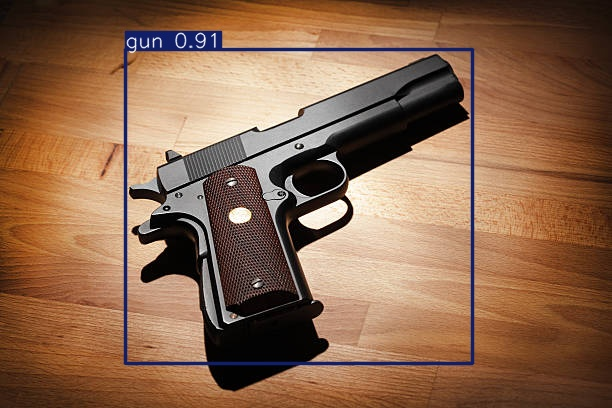

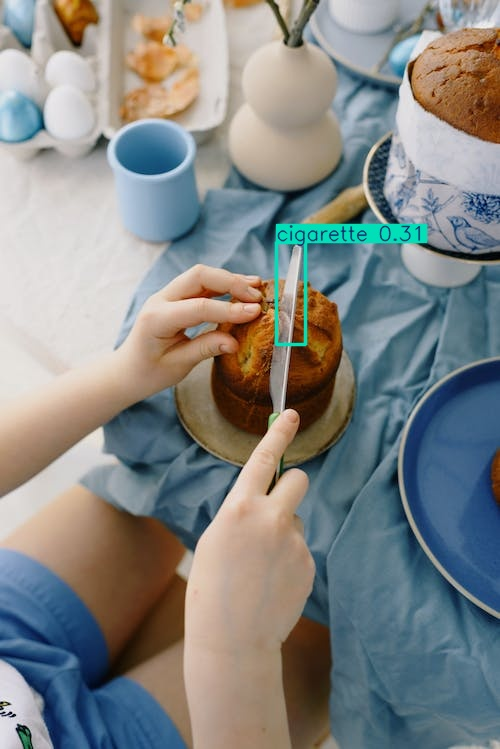

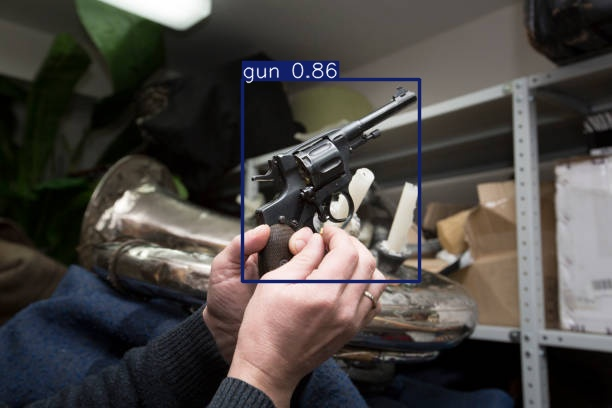

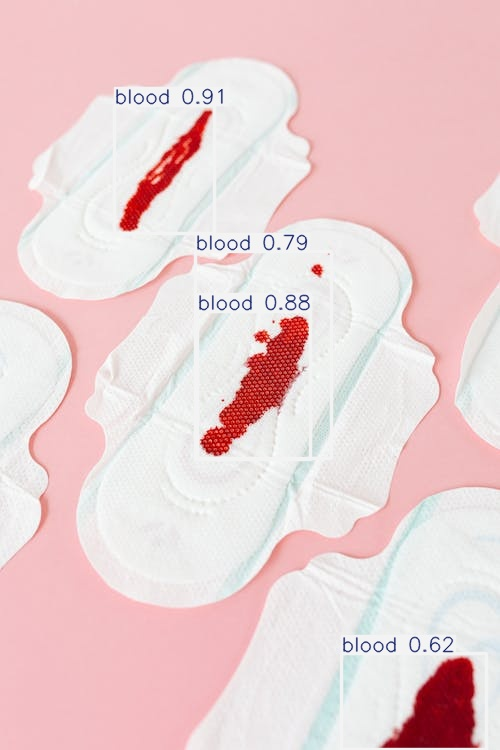

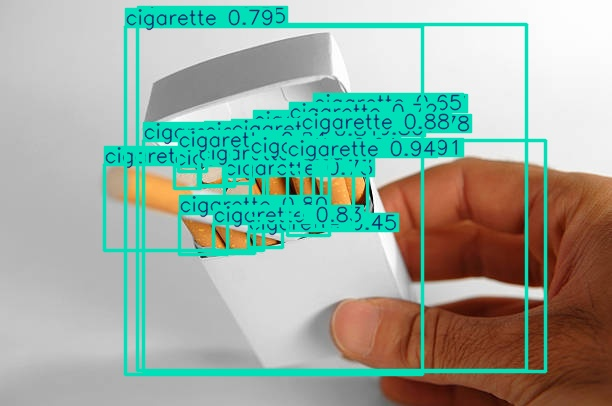

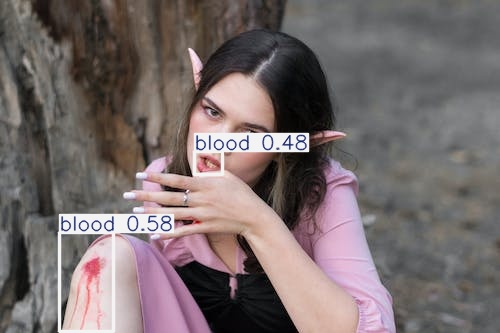

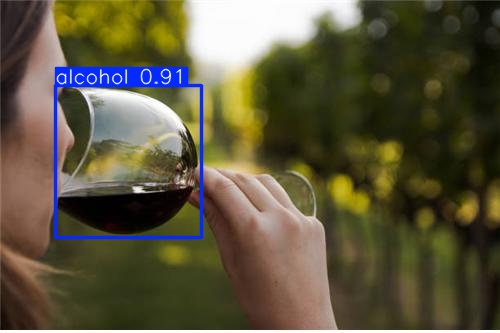

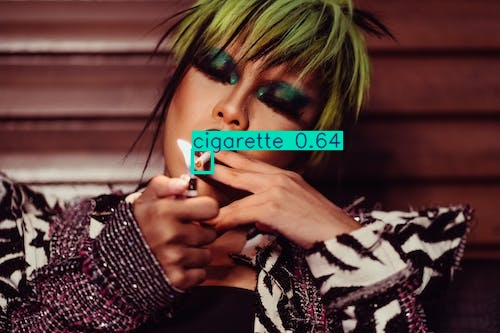

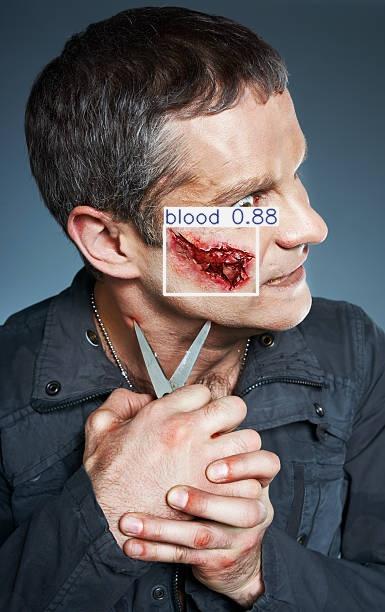

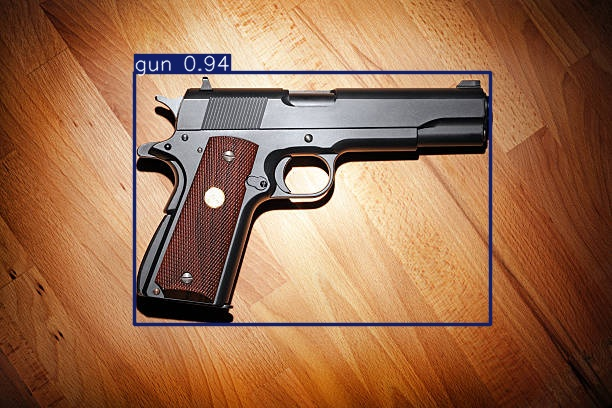

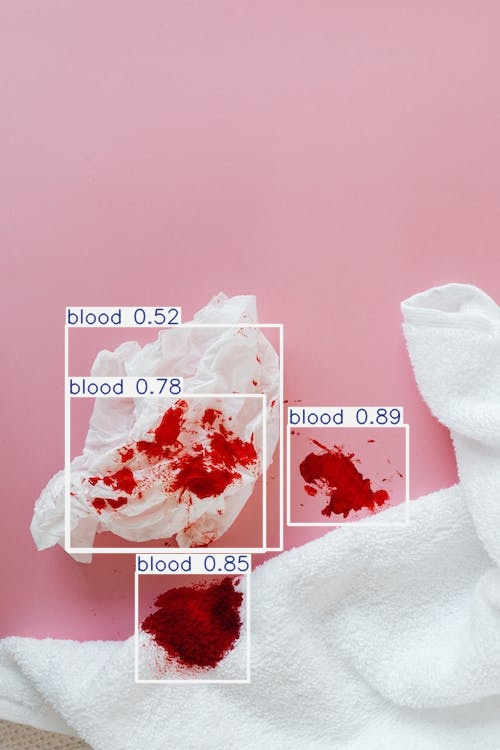

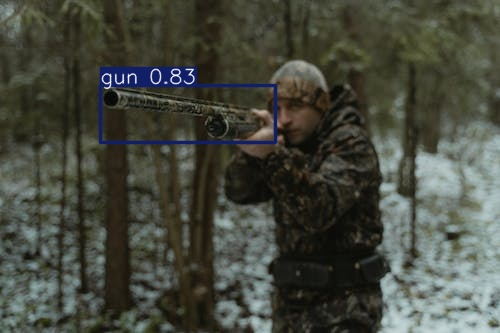

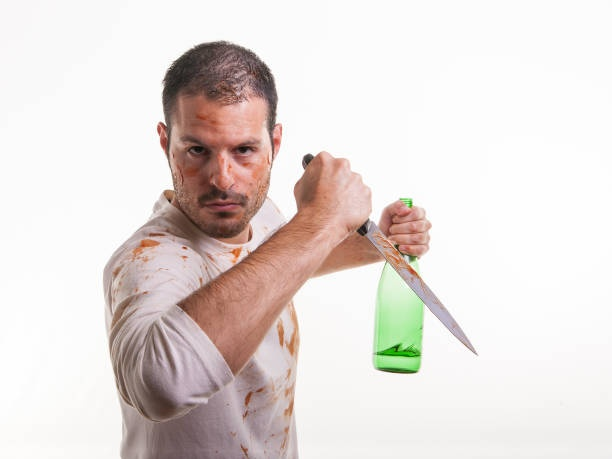

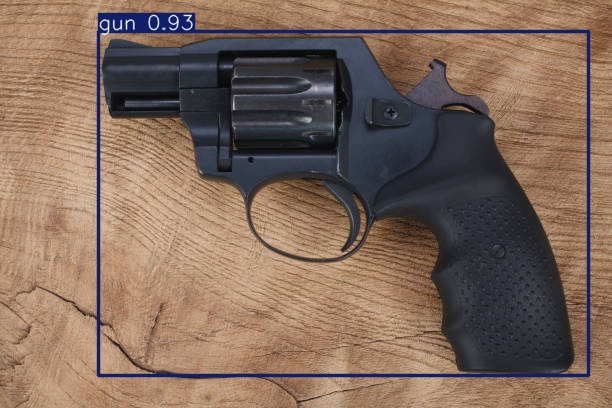

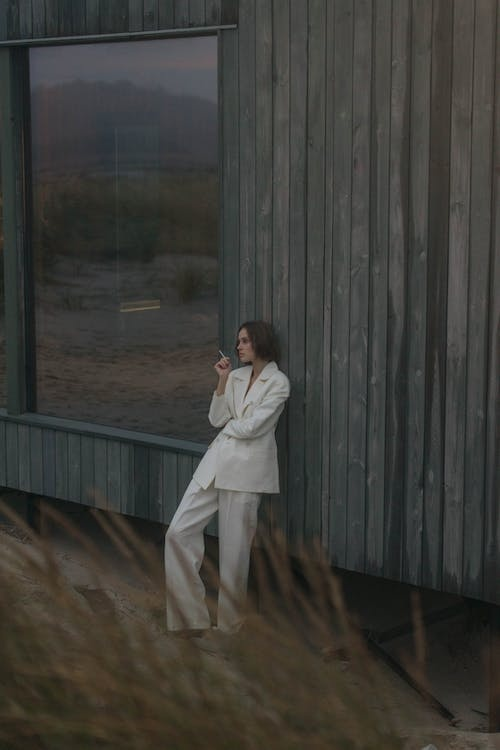

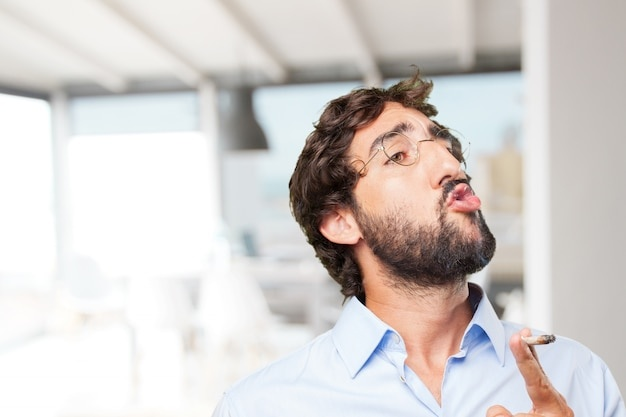

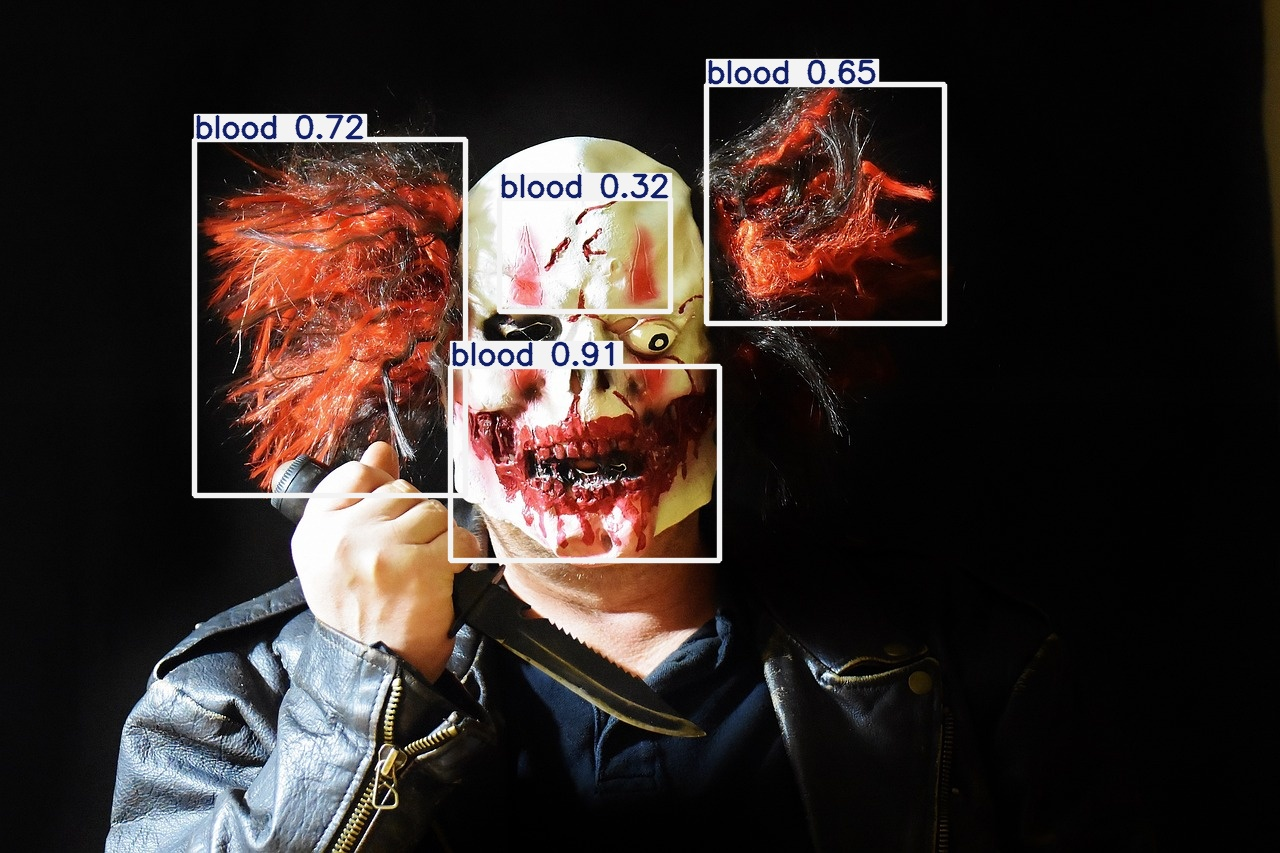

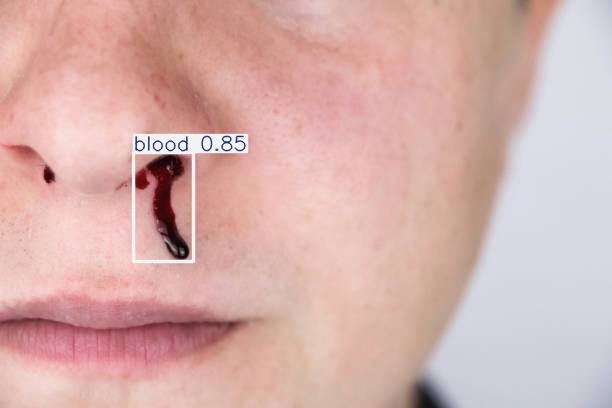

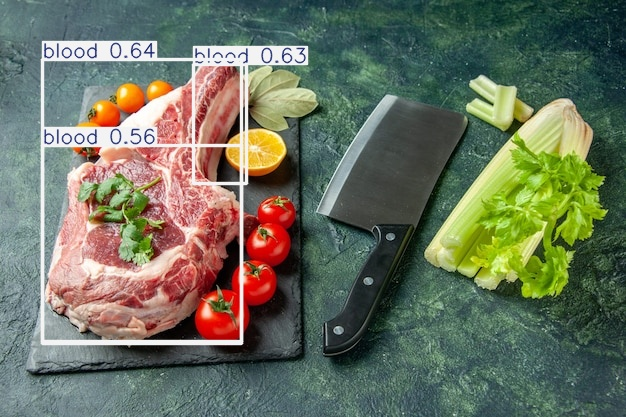

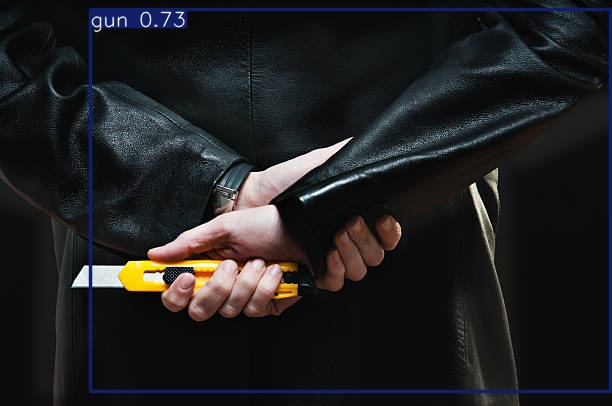

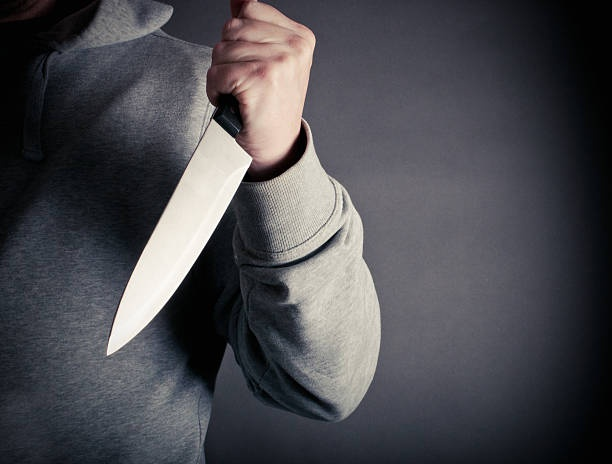

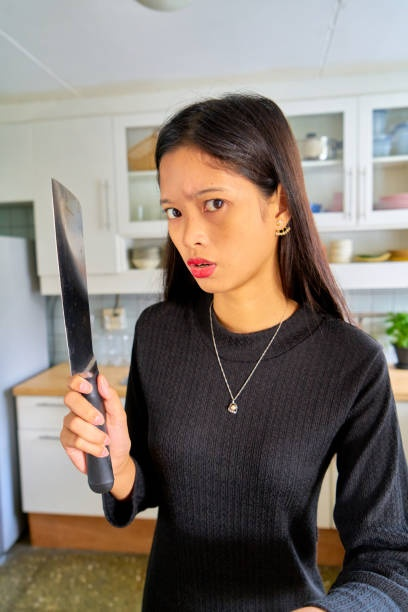

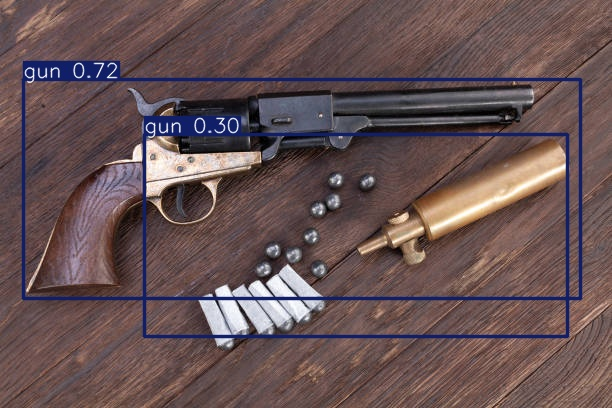

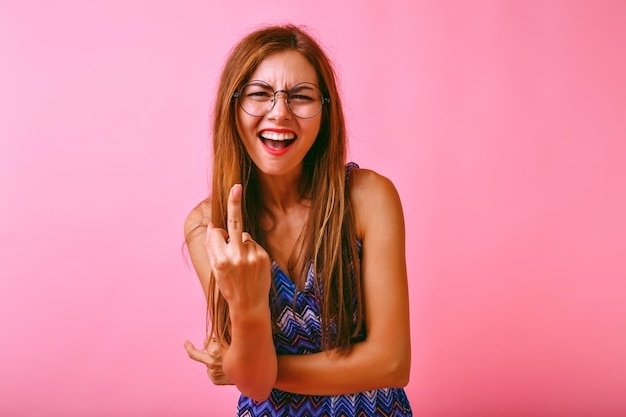

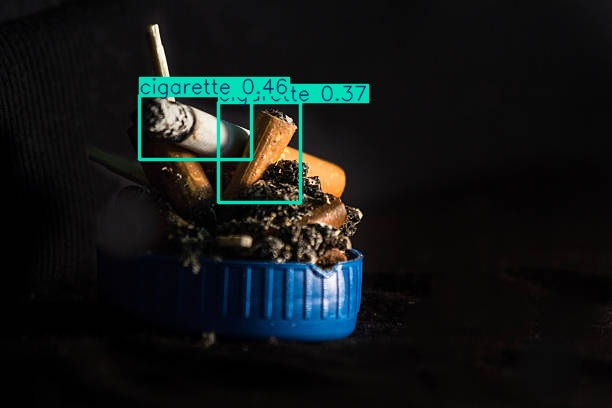

In [ ]:
from IPython.display import Image, display
import glob

# 예측 결과 이미지 불러오기
pred_imgs = glob.glob('runs/detect/best_test/*.jpg')

# 예시: 앞에 5장만 보기
for img in pred_imgs[0:25]:
    display(Image(filename=img))



🖼️ 이미지: img_hod_001451.jpg


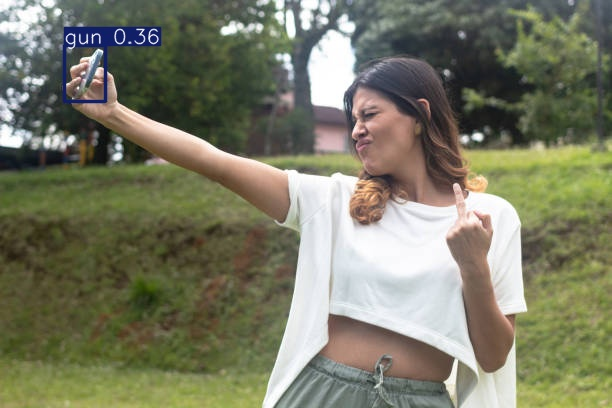

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001459.jpg


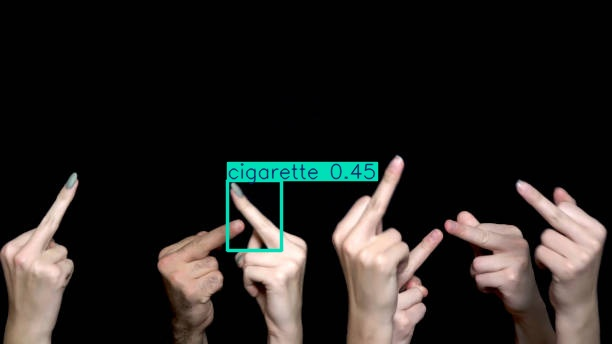

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 1
  - class_id: 1
  - class_id: 1
  - class_id: 1
  - class_id: 1
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001460.jpg


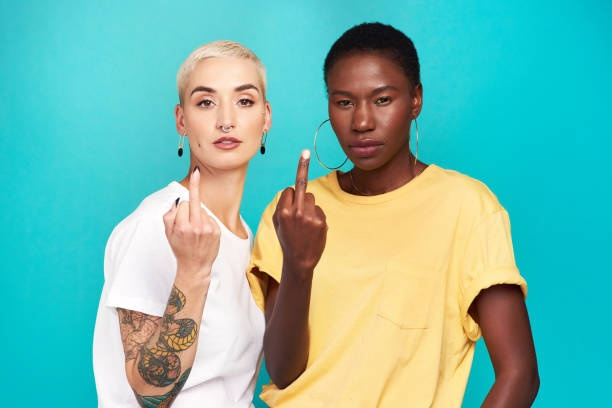

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001470.jpg


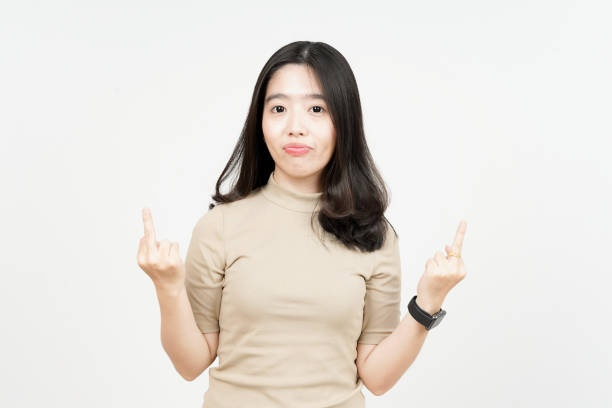

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001474.jpg


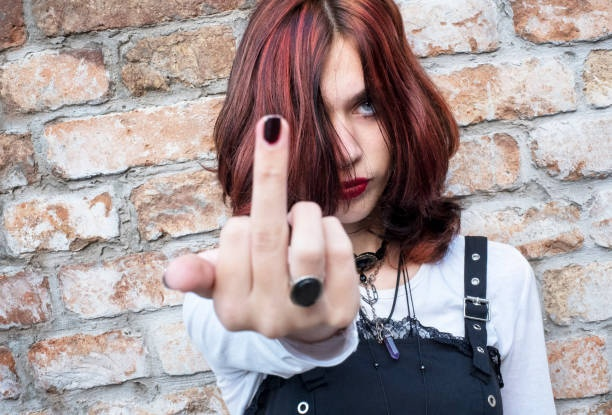

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001477.jpg


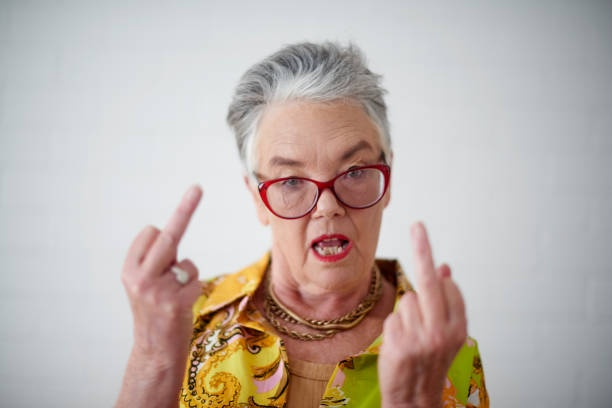

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001479.jpg


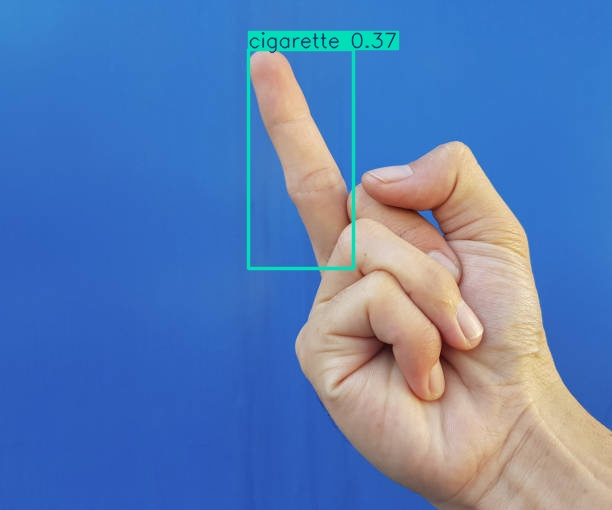

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001486.jpg


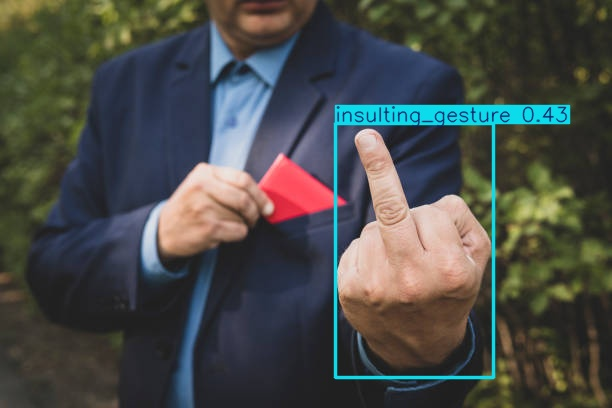

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001493.jpg


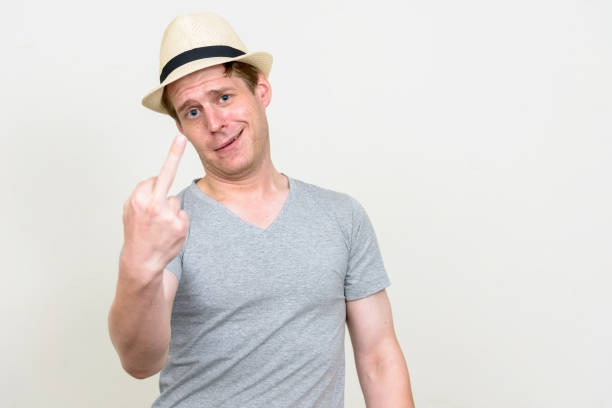

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001505.jpg


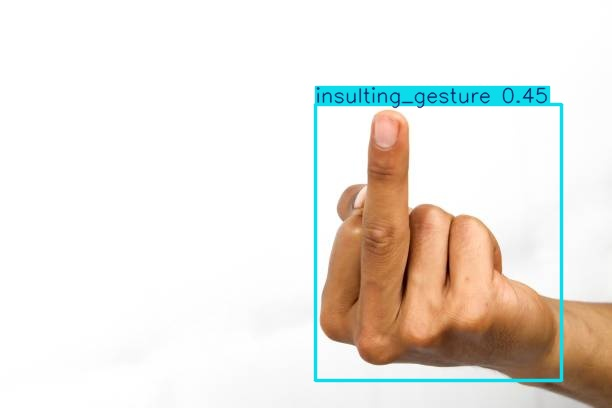

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001519.jpg


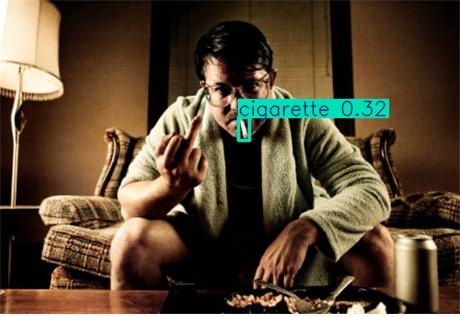

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 3
  - class_id: 1

🖼️ 이미지: img_hod_001520.jpg


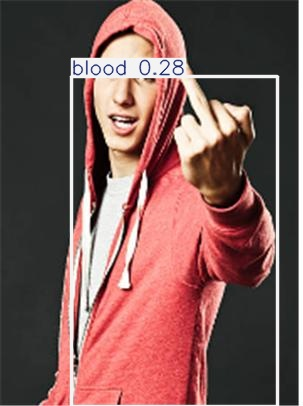

📍 [예측 결과]
  - class_id: 2 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001522.jpg


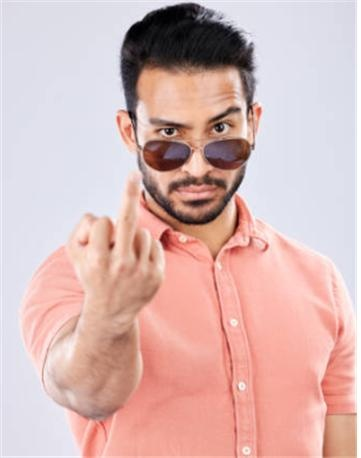

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001523.jpg


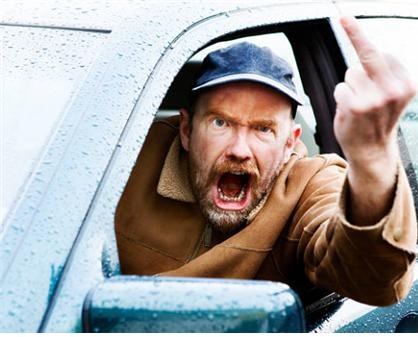

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001542.jpg


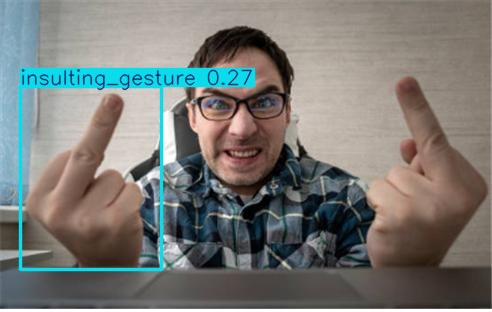

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001580.jpg


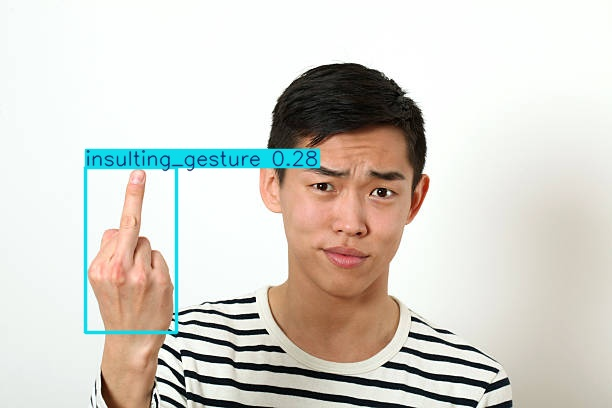

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001586.jpg


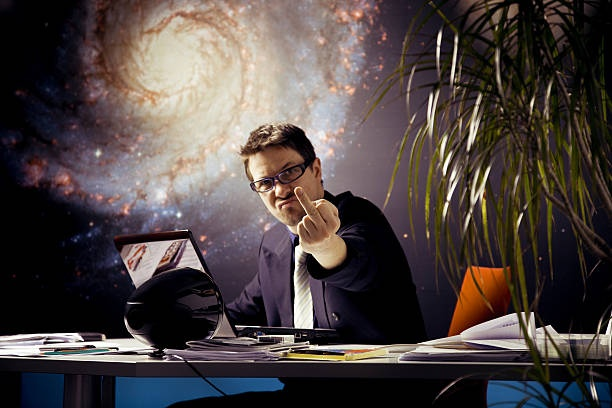

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001587.jpg


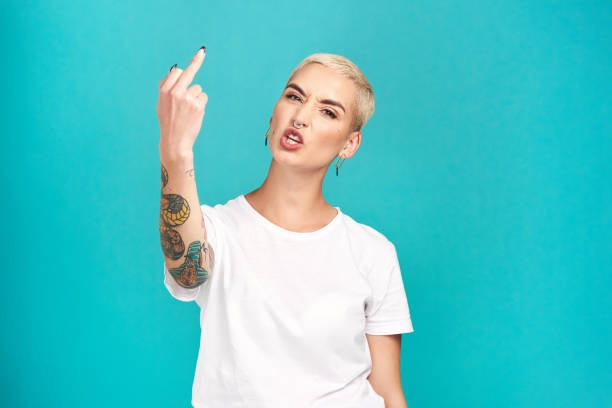

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001590.jpg


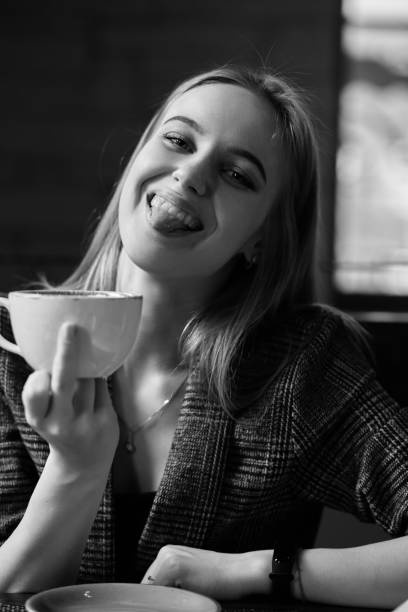

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001591.jpg


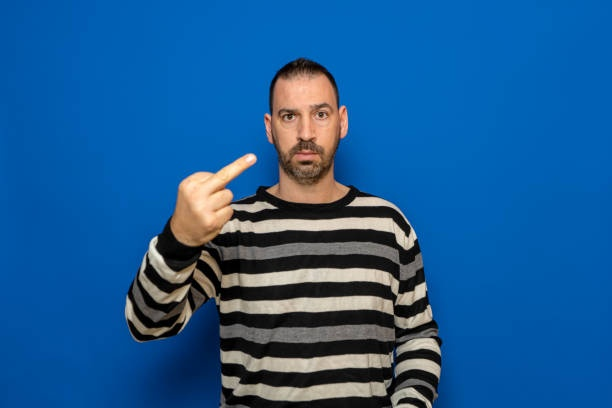

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001597.jpg


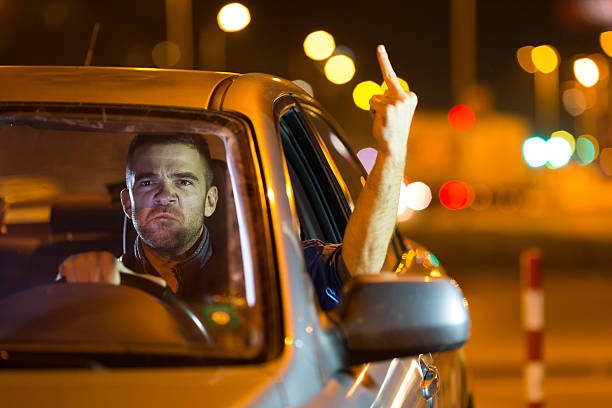

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001625.jpg


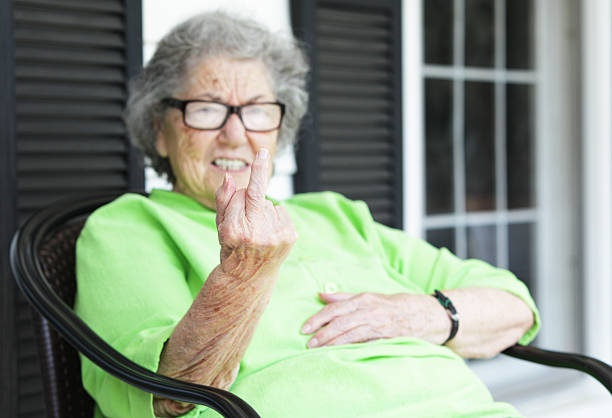

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001632.jpg


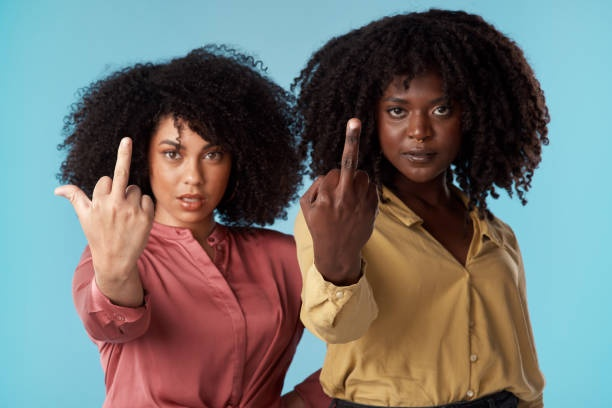

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001647.jpg


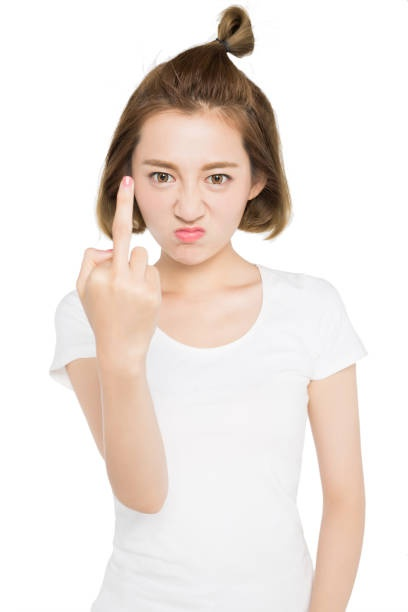

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001663.jpg


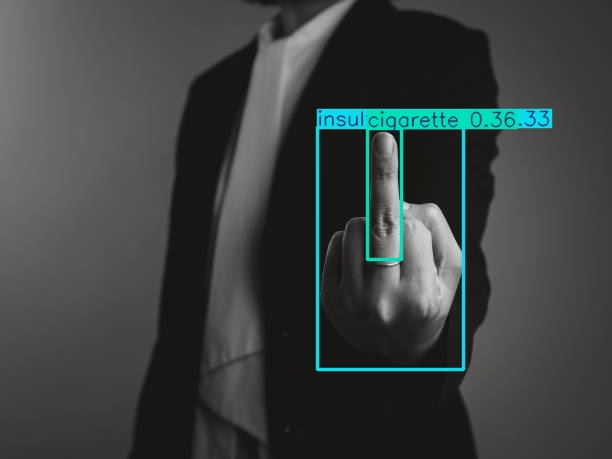

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001680.jpg


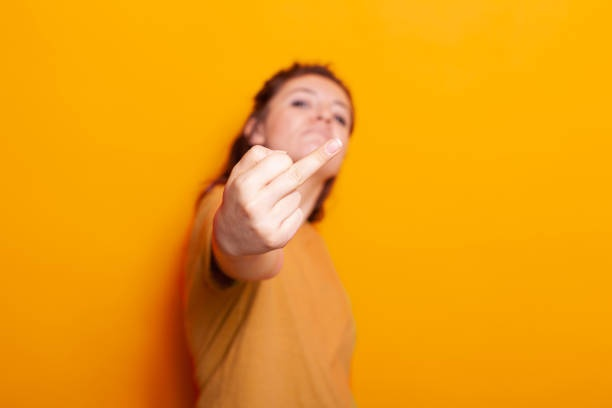

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001682.jpg


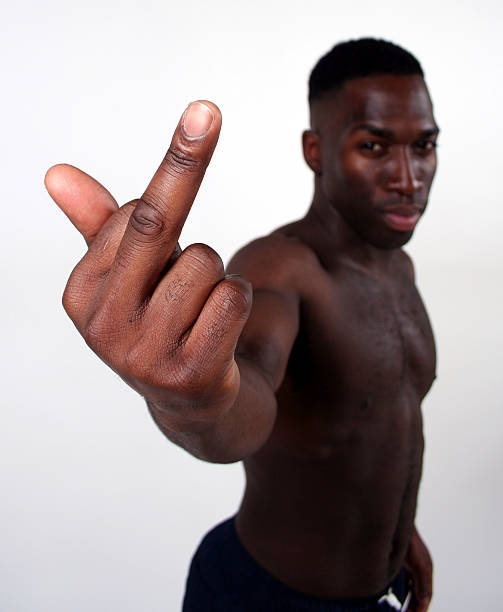

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001697.jpg


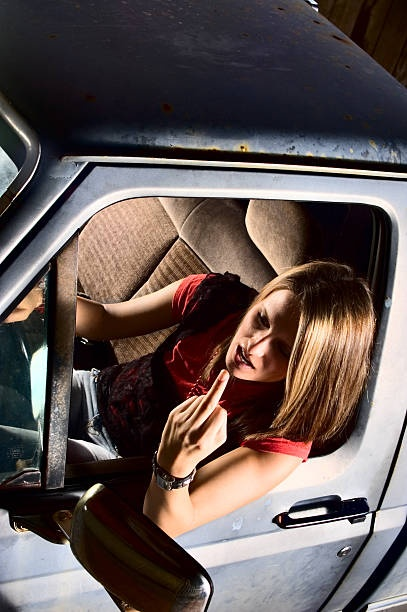

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001700.jpg


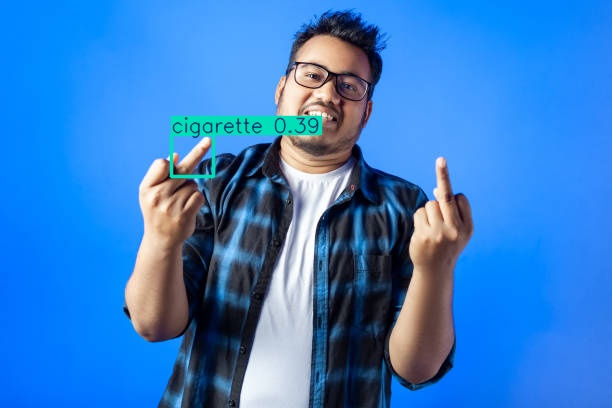

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001716.jpg


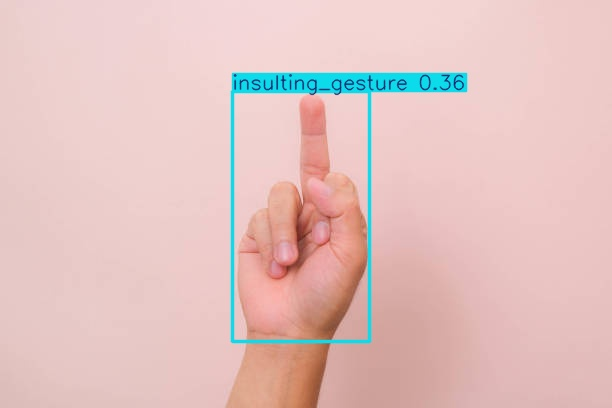

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001721.jpg


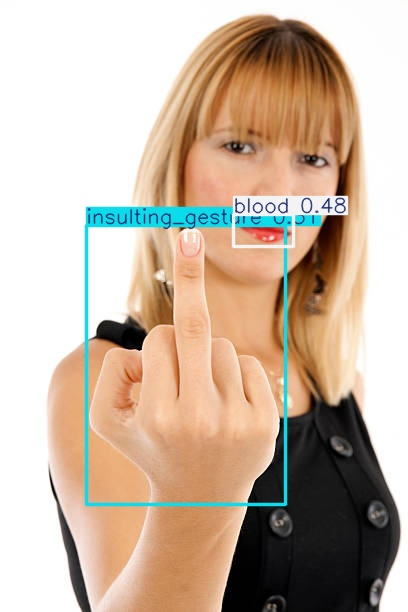

📍 [예측 결과]
  - class_id: 2 (conf: N/A)
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001722.jpg


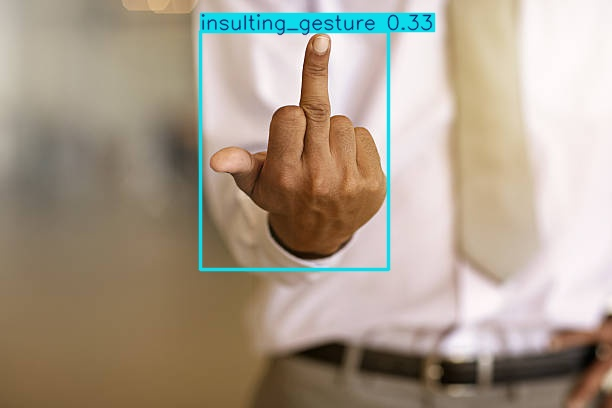

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001757.jpg


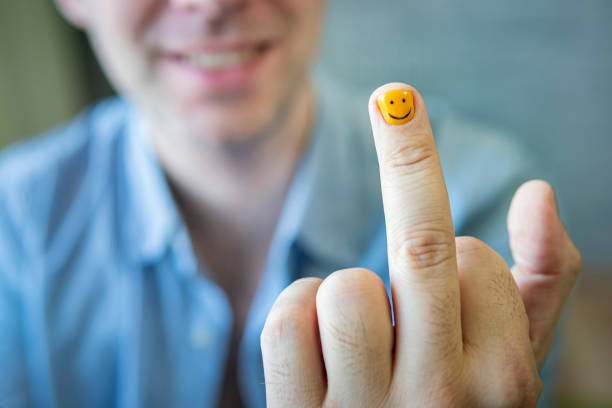

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001764.jpg


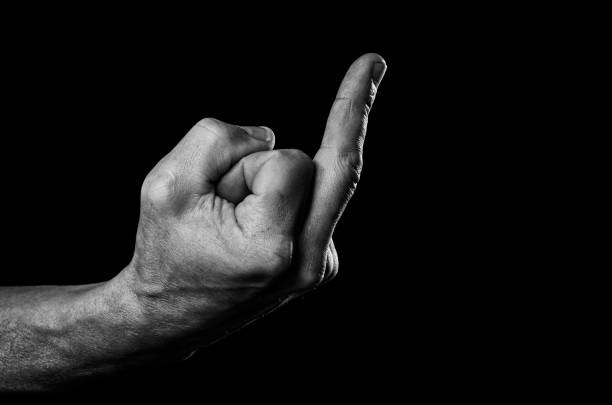

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001773.jpg


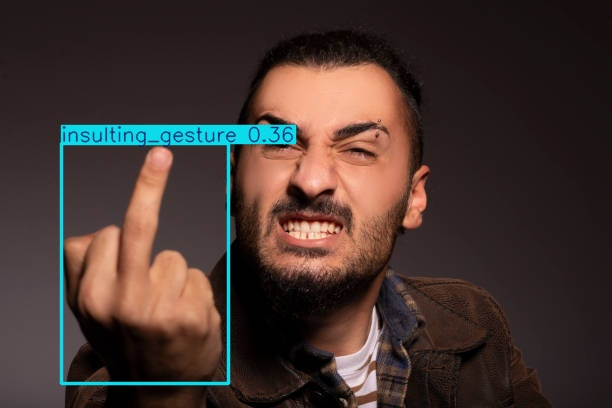

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001776.jpg


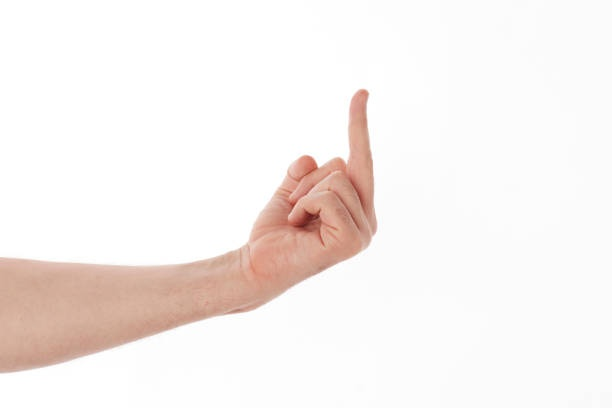

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001797.jpg


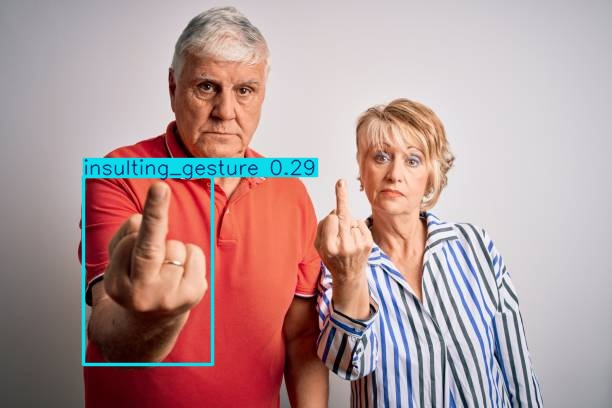

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001808.jpg


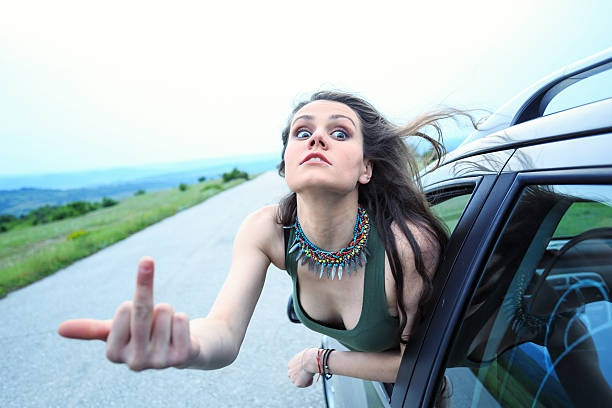

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001810.jpg


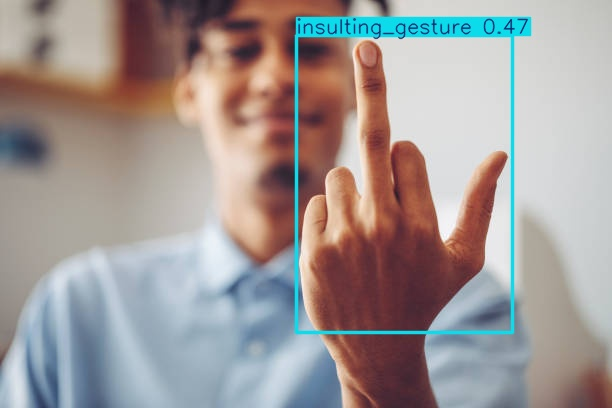

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001816.jpg


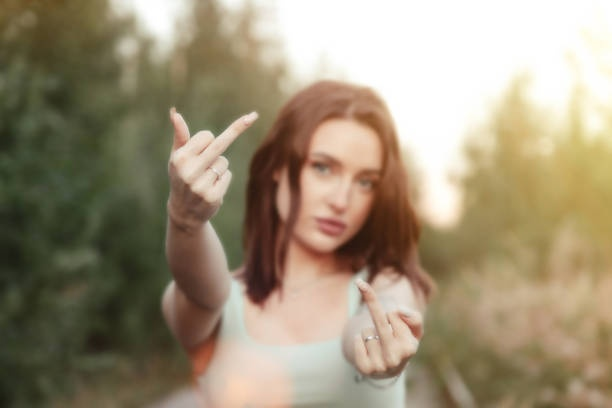

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001818.jpg


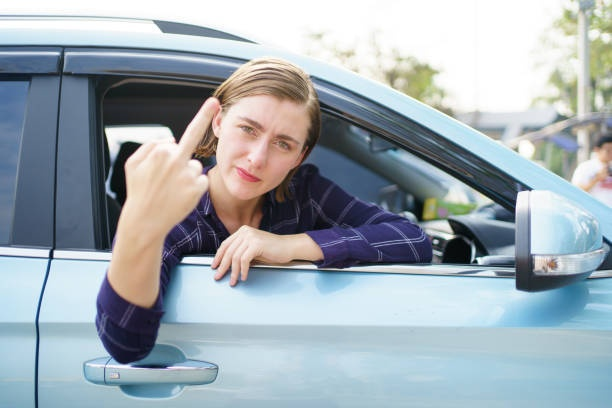

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001839.jpg


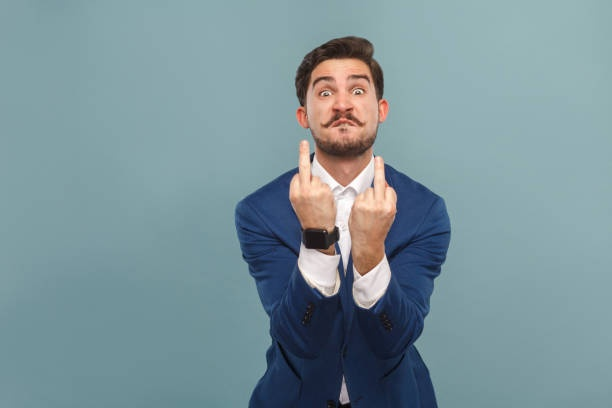

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001856.jpg


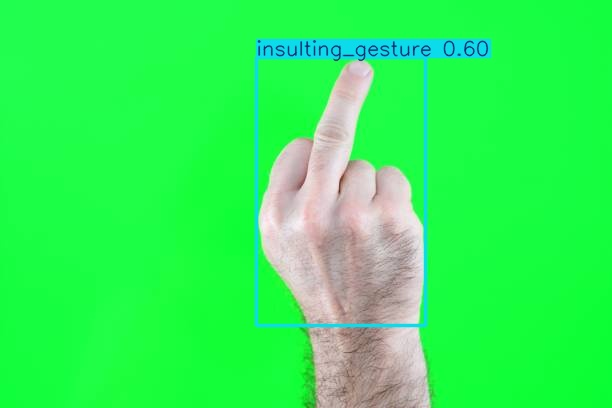

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001884.jpg


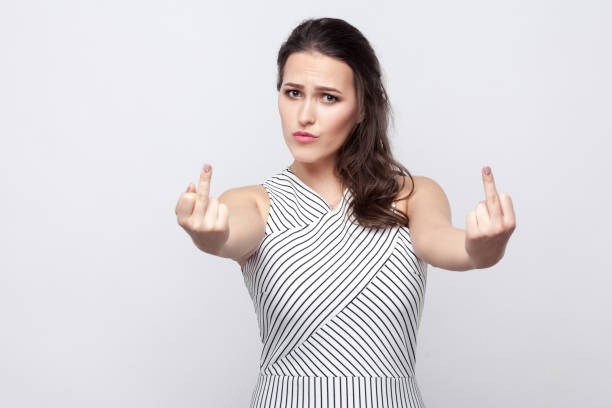

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001886.jpg


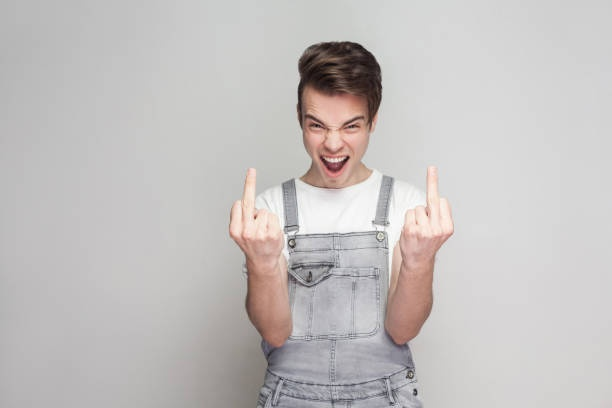

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001906.jpg


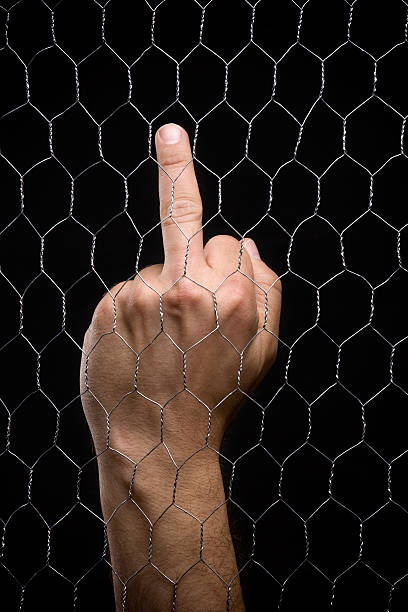

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001944.jpg


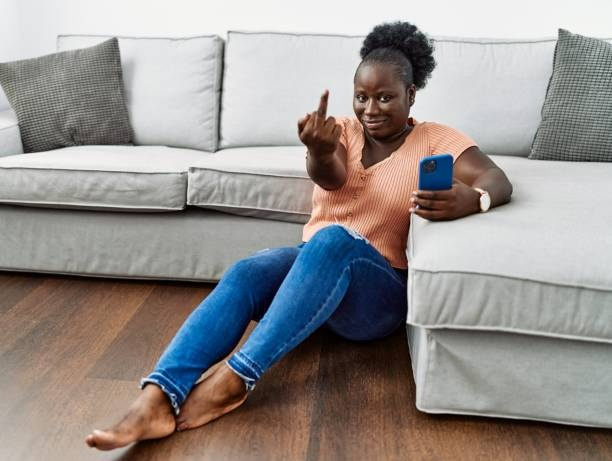

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001951.jpg


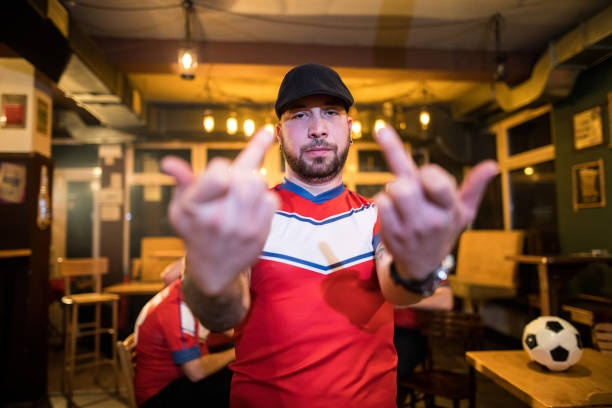

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1
  - class_id: 1

🖼️ 이미지: img_hod_001953.jpg


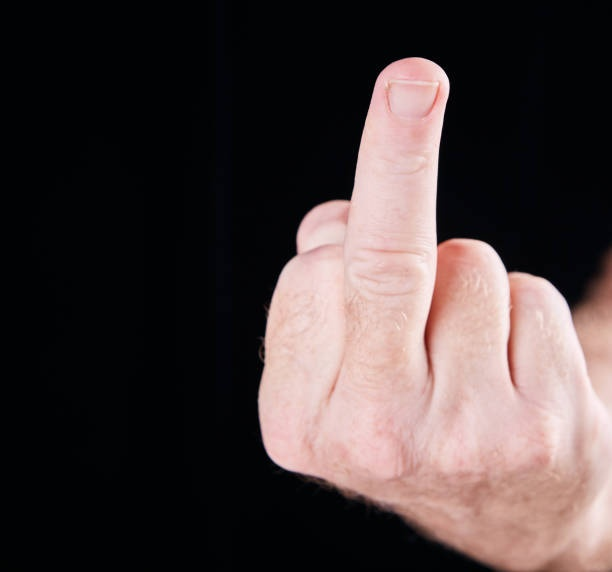

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001962.jpg


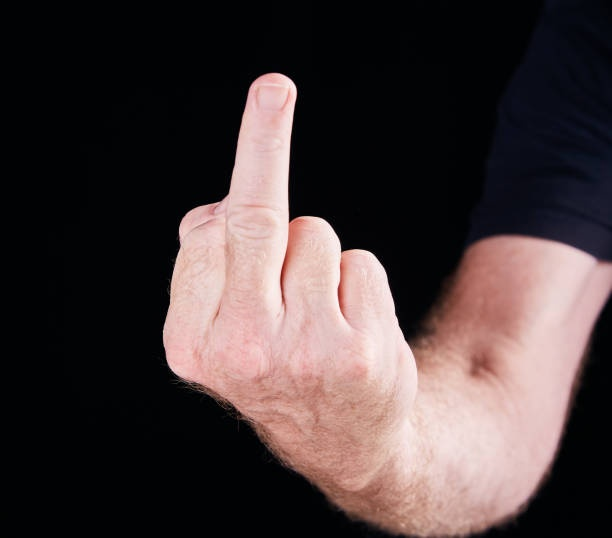

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001974.jpg


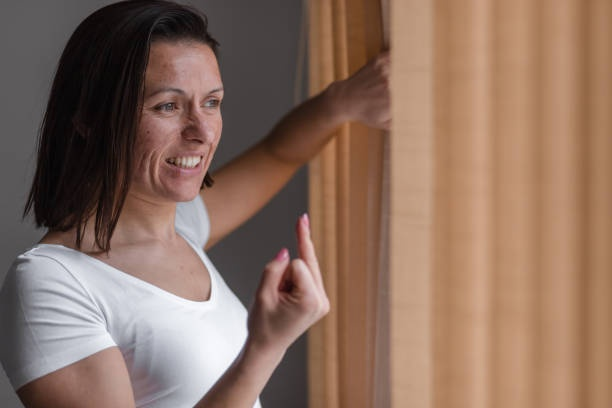

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_001988.jpg


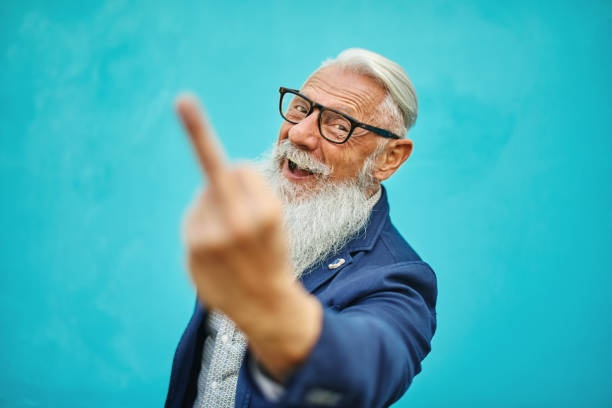

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_002012.jpg


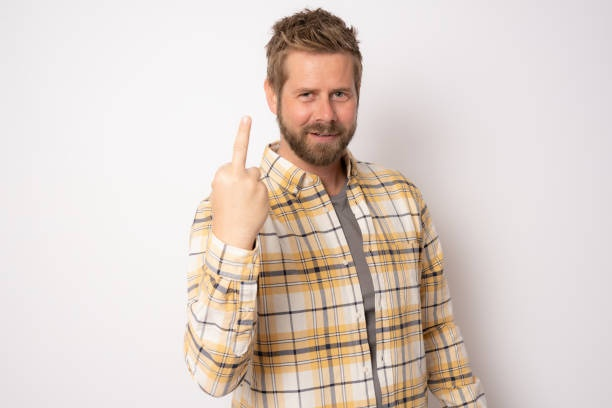

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_002015.jpg


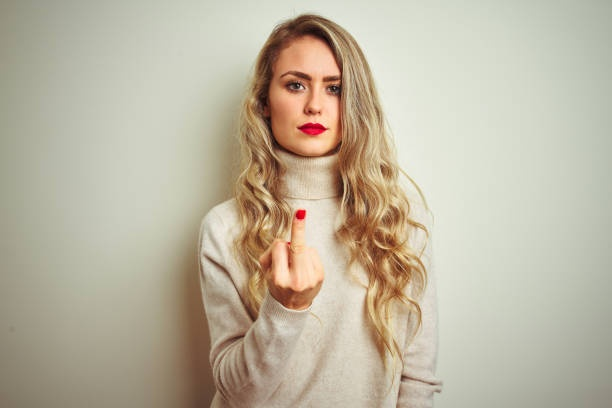

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_002033.jpg


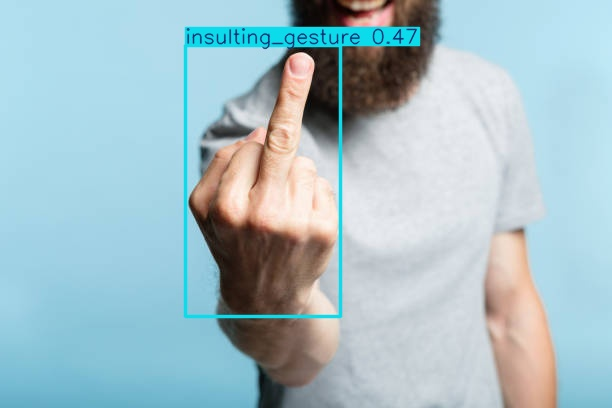

📍 [예측 결과]
  - class_id: 1 (conf: N/A)
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_002039.jpg


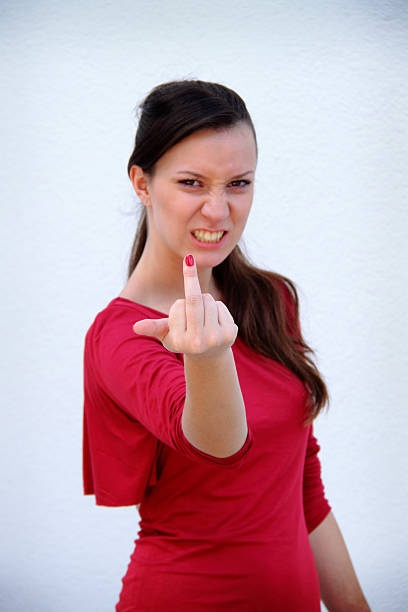

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_002050.jpg


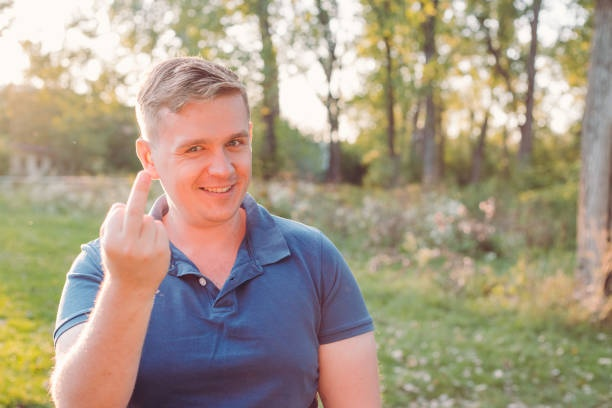

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 1

🖼️ 이미지: img_hod_002075.jpg


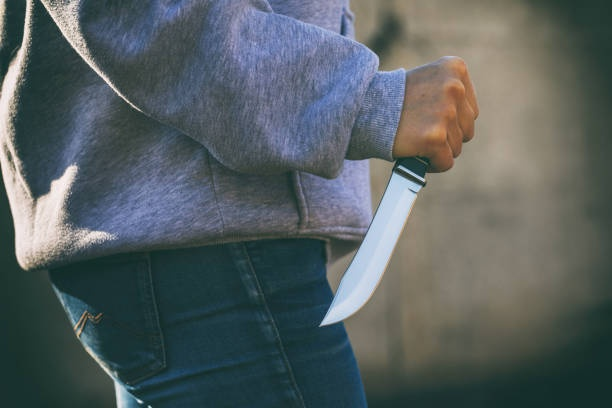

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002091.jpg


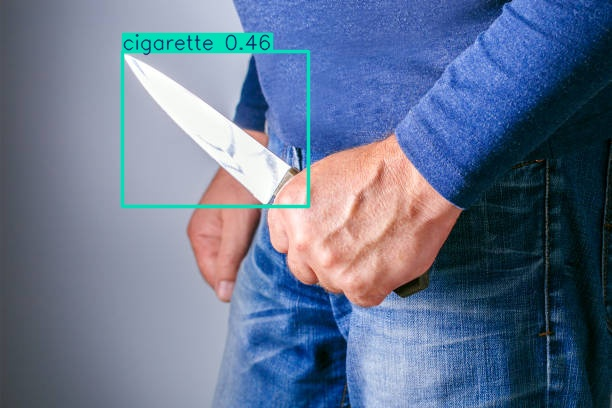

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002099.jpg


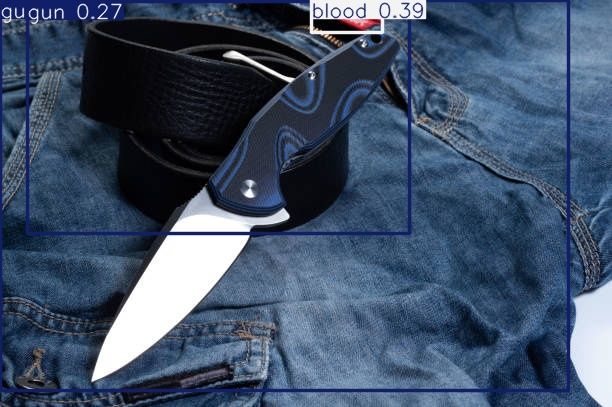

📍 [예측 결과]
  - class_id: 2 (conf: N/A)
  - class_id: 4 (conf: N/A)
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002102.jpg


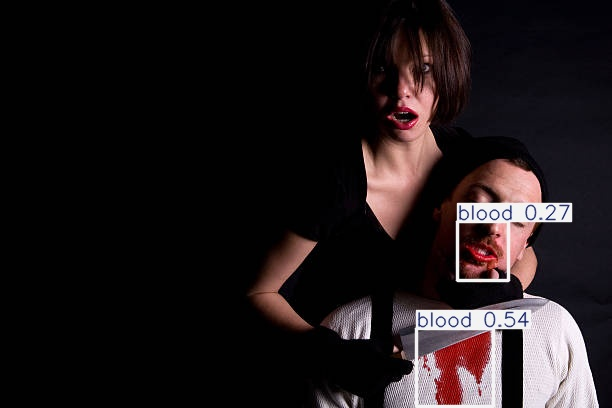

📍 [예측 결과]
  - class_id: 2 (conf: N/A)
  - class_id: 2 (conf: N/A)
✅ [실제 정답]
  - class_id: 2
  - class_id: 5

🖼️ 이미지: img_hod_002113.jpg


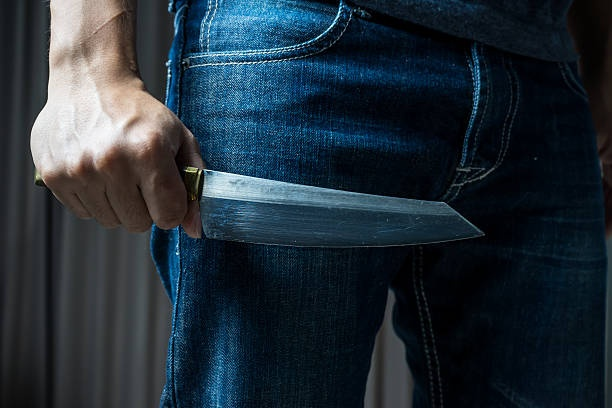

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002156.jpg


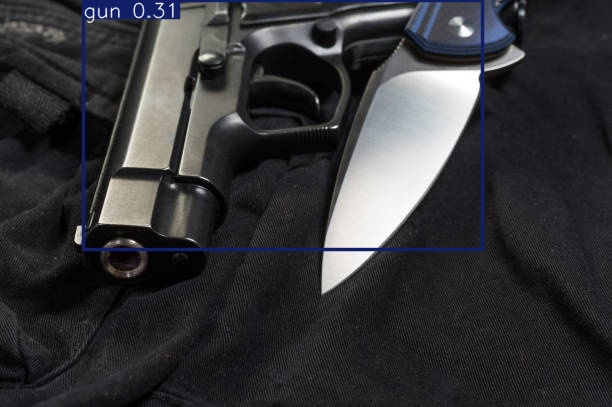

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 4
  - class_id: 5

🖼️ 이미지: img_hod_002157.jpg


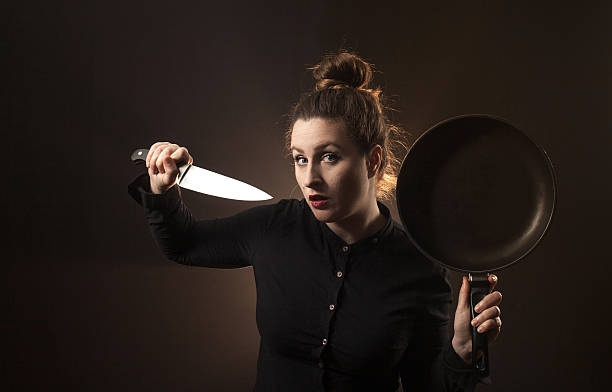

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002178.jpg


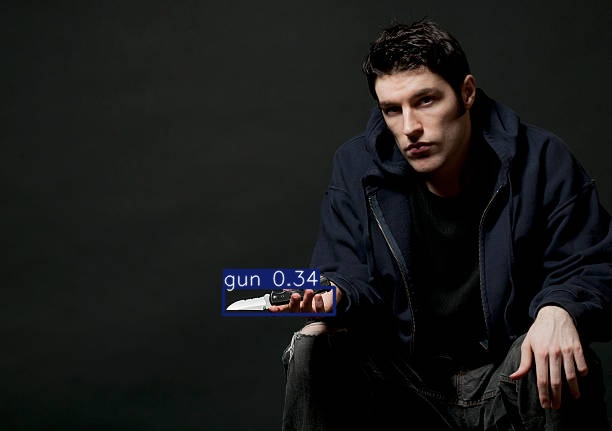

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002221.jpg


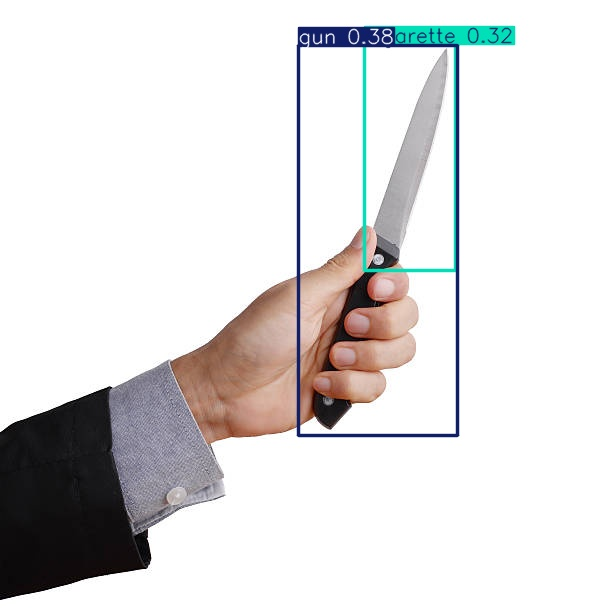

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002245.jpg


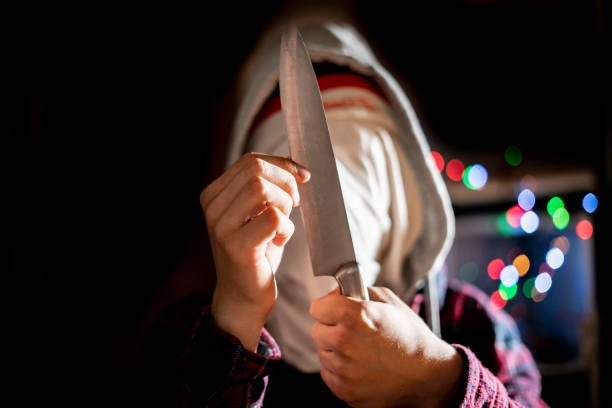

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002247.jpg


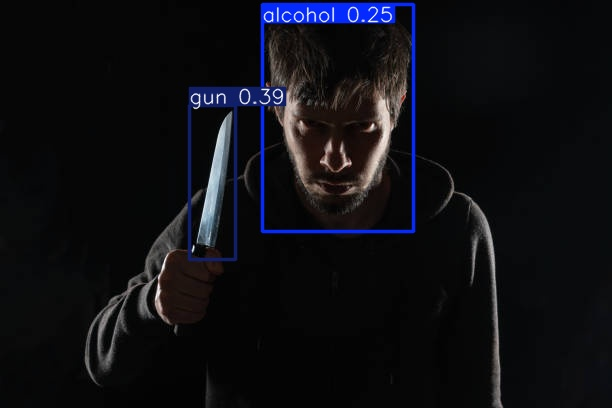

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
  - class_id: 0 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002260.jpg


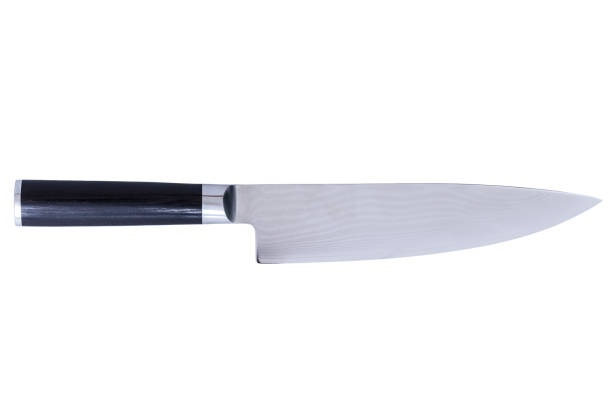

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002269.jpg


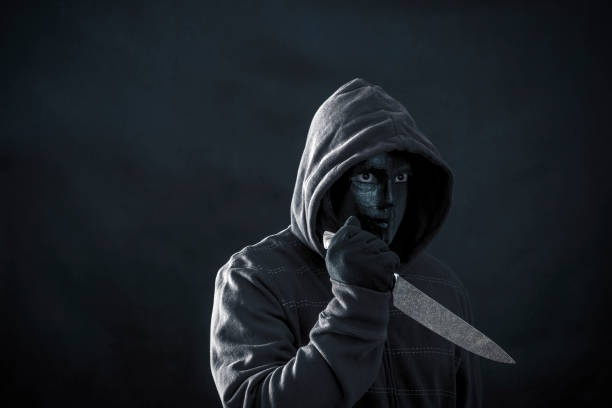

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002280.jpg


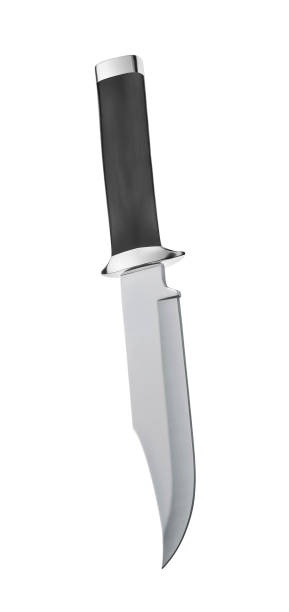

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002289.jpg


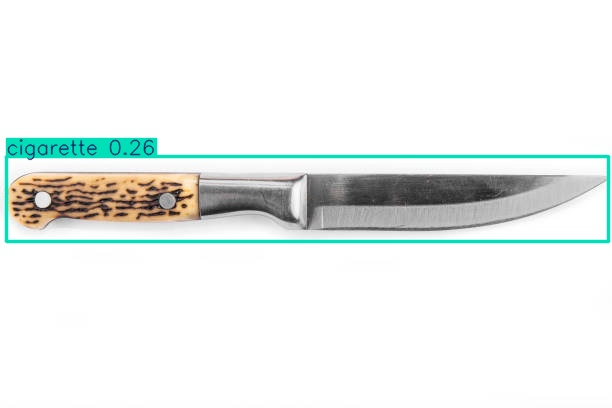

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002290.jpg


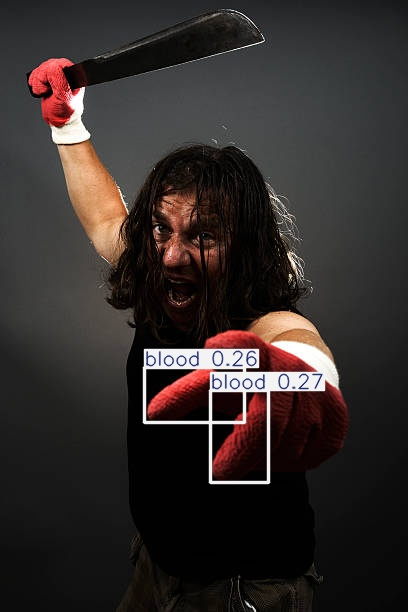

📍 [예측 결과]
  - class_id: 2 (conf: N/A)
  - class_id: 2 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002300.jpg


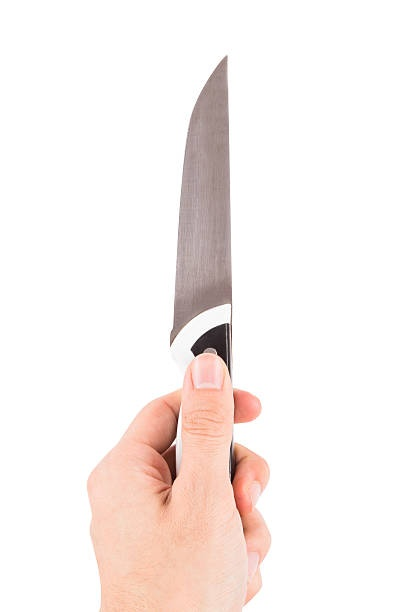

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002312.jpg


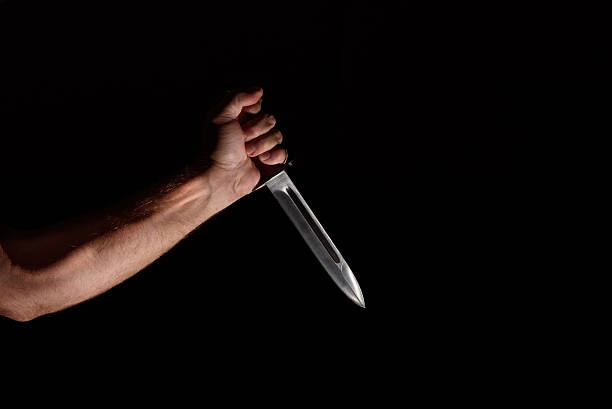

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002320.jpg


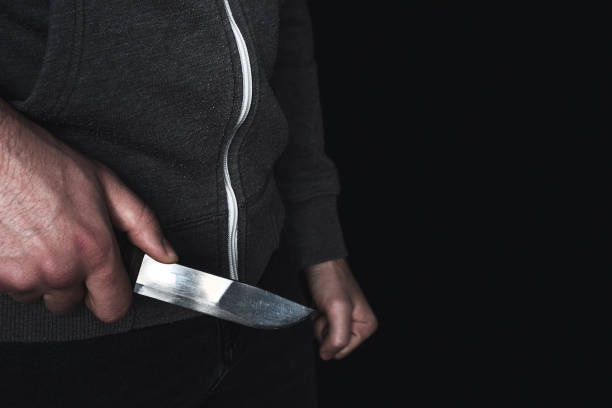

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002321.jpg


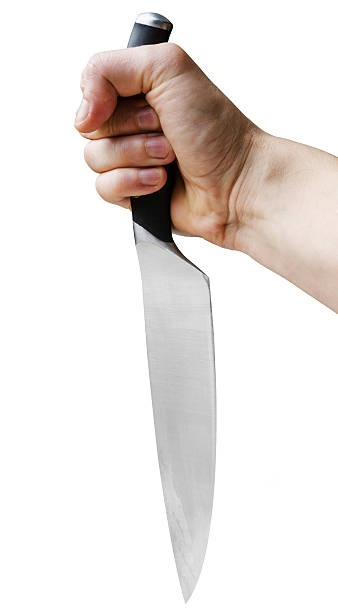

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002328.jpg


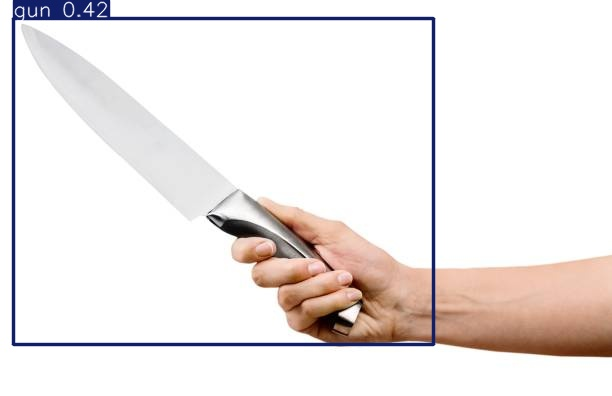

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002331.jpg


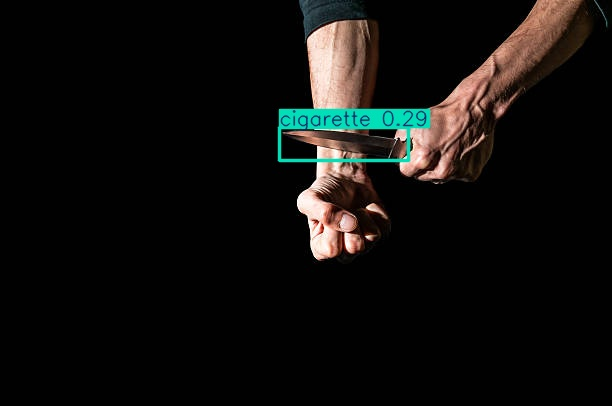

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002358.jpg


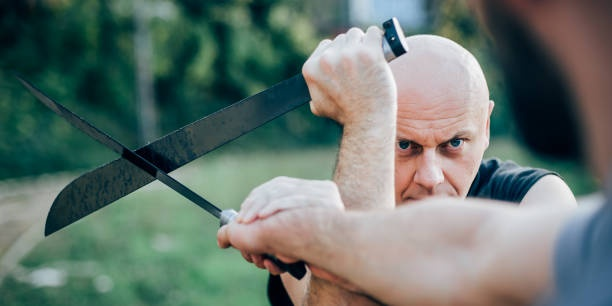

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5
  - class_id: 5

🖼️ 이미지: img_hod_002360.jpg


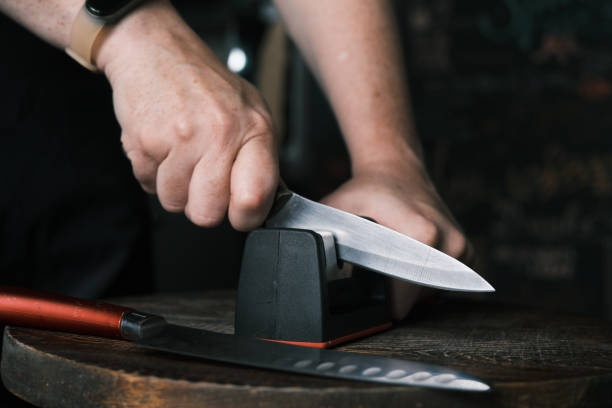

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5
  - class_id: 5

🖼️ 이미지: img_hod_002361.jpg


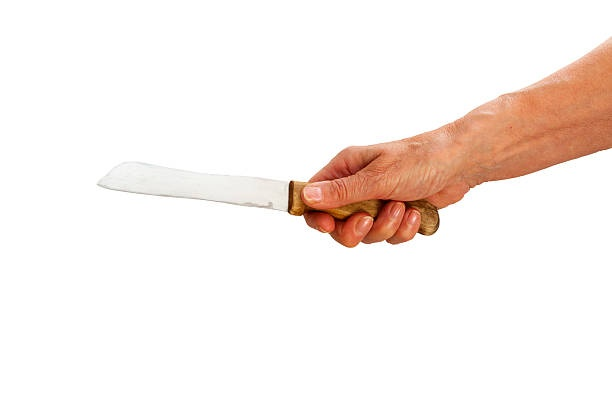

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002371.jpg


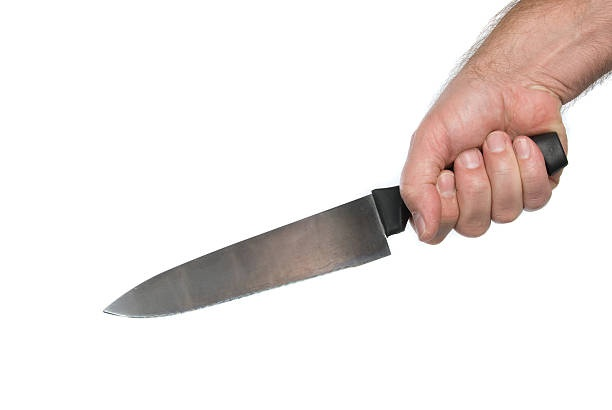

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002374.jpg


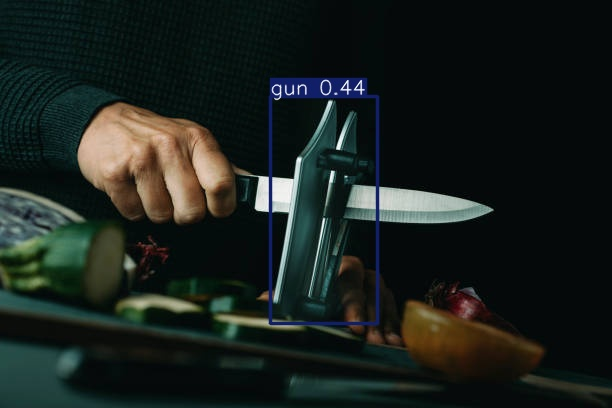

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002380.jpg


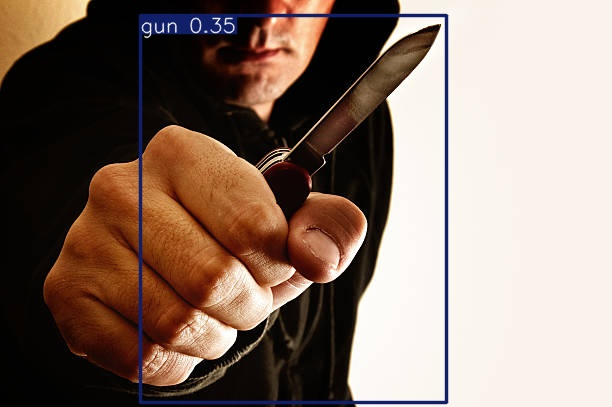

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002394.jpg


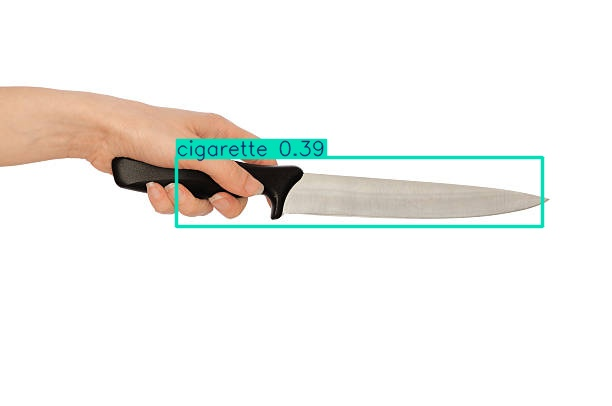

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002397.jpg


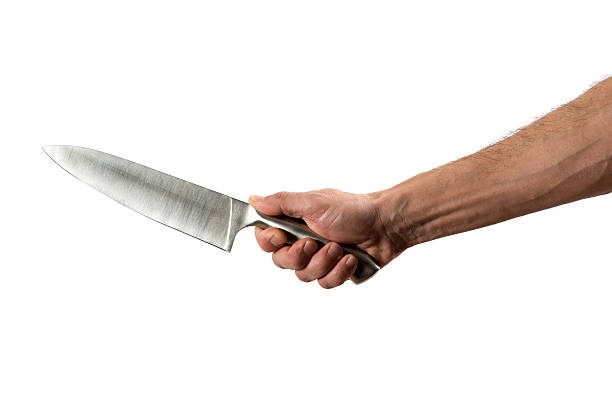

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002411.jpg


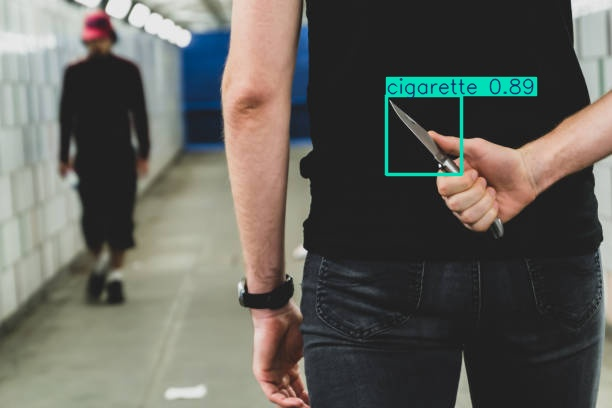

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002417.jpg


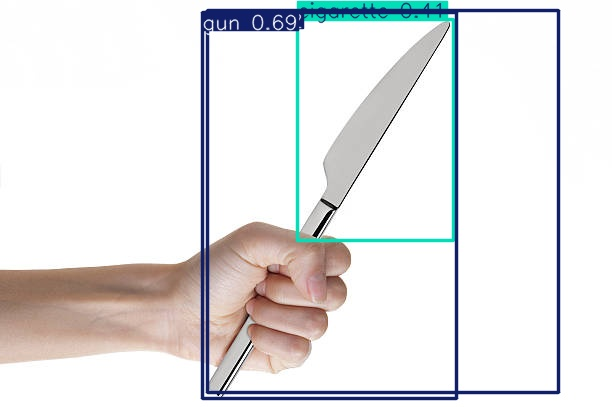

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
  - class_id: 4 (conf: N/A)
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002424.jpg


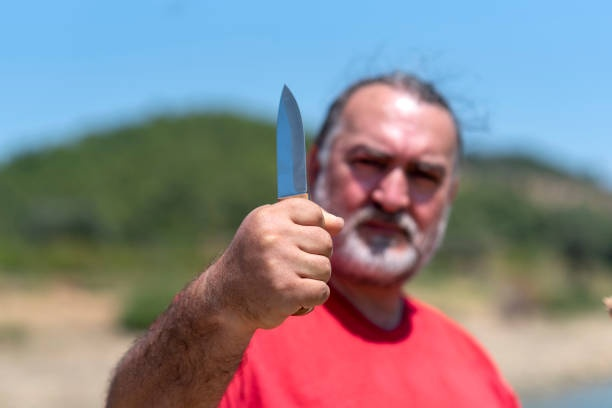

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002430.jpg


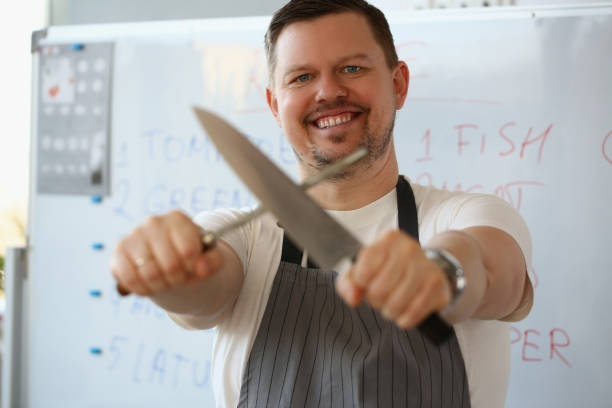

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002435.jpg


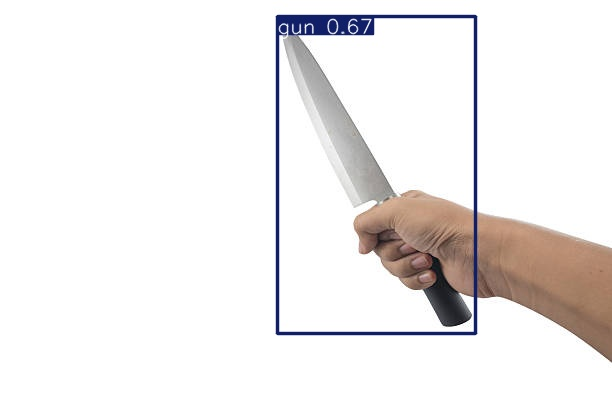

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002438.jpg


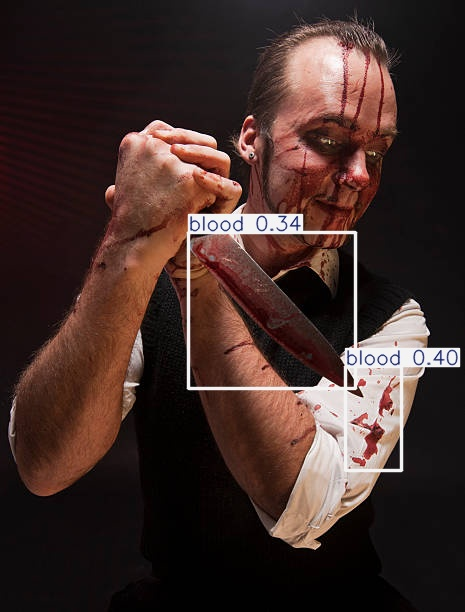

📍 [예측 결과]
  - class_id: 2 (conf: N/A)
  - class_id: 2 (conf: N/A)
✅ [실제 정답]
  - class_id: 2
  - class_id: 2
  - class_id: 2
  - class_id: 2
  - class_id: 5
  - class_id: 2
  - class_id: 2

🖼️ 이미지: img_hod_002458.jpg


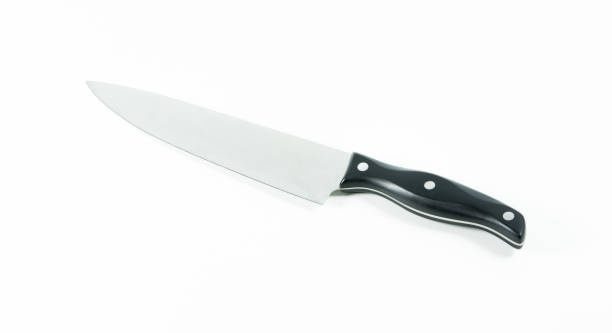

📍 [예측 결과] 없음
✅ [실제 정답]
  - class_id: 5
  - class_id: 5

🖼️ 이미지: img_hod_002466.jpg


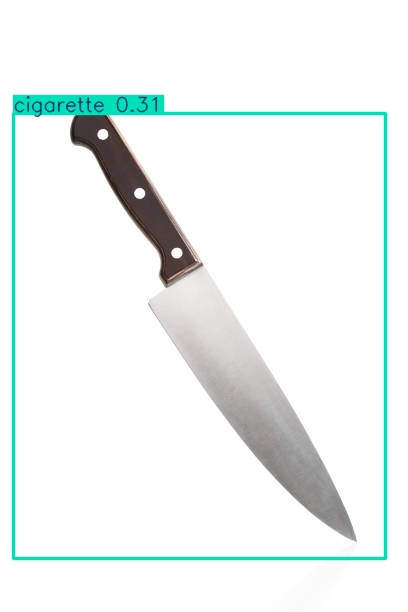

📍 [예측 결과]
  - class_id: 3 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002476.jpg


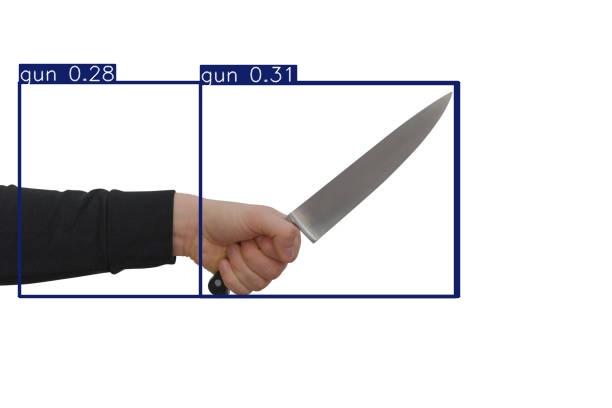

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002497.jpg


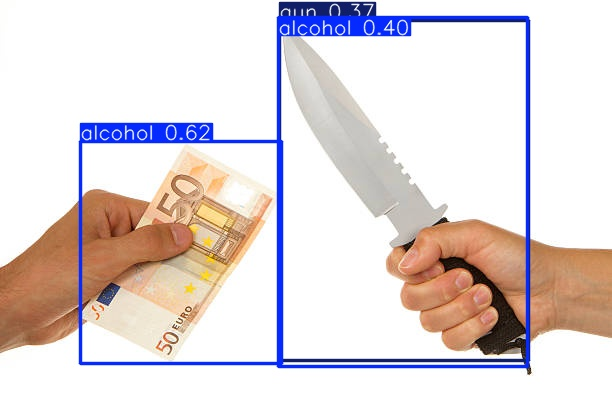

📍 [예측 결과]
  - class_id: 0 (conf: N/A)
  - class_id: 0 (conf: N/A)
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002509.jpg


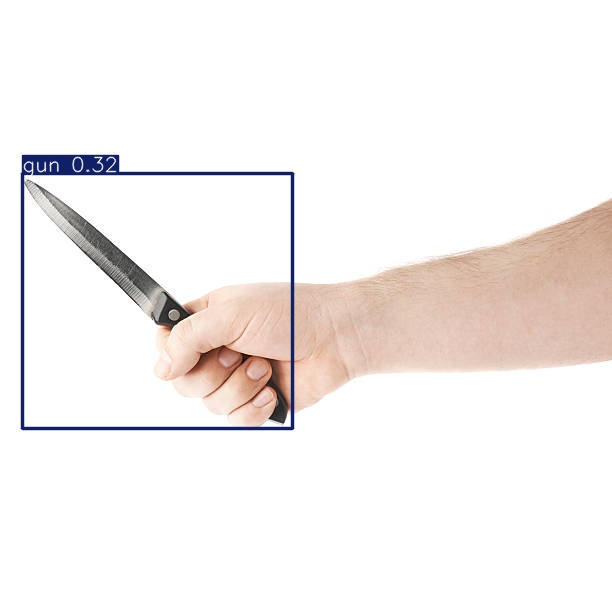

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5
  - class_id: 5

🖼️ 이미지: img_hod_002520.jpg


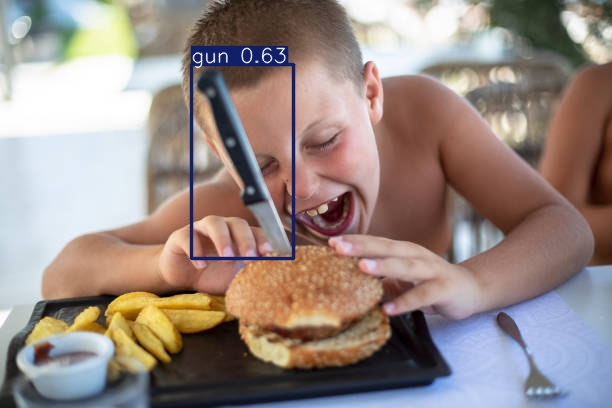

📍 [예측 결과]
  - class_id: 4 (conf: N/A)
✅ [실제 정답]
  - class_id: 5

🖼️ 이미지: img_hod_002533.jpg


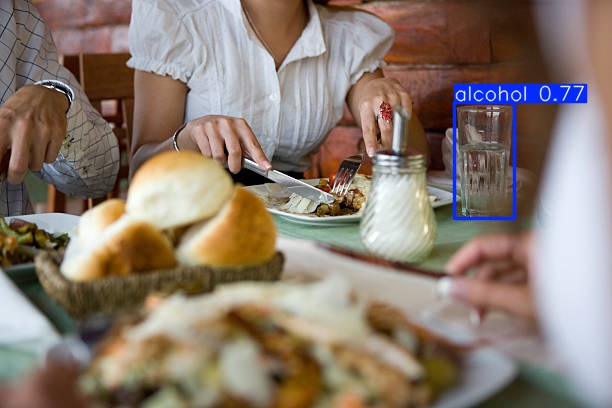

📍 [예측 결과]
  - class_id: 0 (conf: N/A)
✅ [실제 정답]
  - class_id: 5


In [ ]:
import os
from IPython.display import display, Image
import glob

pred_dir = 'runs/detect/best_test'
label_dir = os.path.join(pred_dir, 'labels')  # 예측된 결과 라벨
true_label_dir = '/content/drive/MyDrive/blurit_dataset_yolo/combined_all/labels/val'  # 실제 정답

img_paths = sorted(glob.glob(f'{pred_dir}/*.jpg'))[150:250]



for img_path in img_paths:
    base = os.path.basename(img_path).replace('.jpg', '')
    pred_label_file = os.path.join(label_dir, f'{base}.txt')
    true_label_file = os.path.join(true_label_dir, f'{base}.txt')

    print(f"\n🖼️ 이미지: {base}.jpg")
    display(Image(filename=img_path))

    # 예측 결과
    if os.path.exists(pred_label_file):
        print("📍 [예측 결과]")
        with open(pred_label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 6:
                    cls, x, y, w, h, conf = parts
                    print(f"  - class_id: {cls}, conf: {float(conf):.2f}")
                elif len(parts) == 5:
                    cls, x, y, w, h = parts
                    print(f"  - class_id: {cls} (conf: N/A)")
                else:
                    print("  ⚠️ 예측 포맷 오류:", line.strip())
    else:
        print("📍 [예측 결과] 없음")

    # 실제 정답
    if os.path.exists(true_label_file):
        print("✅ [실제 정답]")
        with open(true_label_file, 'r') as f:
            for line in f:
                cls, x, y, w, h = line.strip().split()
                print(f"  - class_id: {cls}")
    else:
        print("✅ [실제 정답] 없음")


## 데이터셋 조정 후 테스트

In [ ]:
import os
import shutil
from glob import glob

# 설정
SOURCE_BASE = "/content/drive/MyDrive/blurit_dataset_yolo"
TARGET_BASE = "./blurit_yolo_ready"
CLASSES = ['alcohol', 'insulting_gesture', 'blood', 'cigarette', 'gun', 'knife']
SPLITS = ['train', 'val', 'test']
MODES = ['normal', 'hard']  # 난이도 분류

# class_name → class_id
class_id_map = {cls: i for i, cls in enumerate(CLASSES)}

# 타겟 디렉토리 준비 (normal, hard, all)
targets = {
    'normal': os.path.join(TARGET_BASE, 'normal'),
    'hard': os.path.join(TARGET_BASE, 'hard'),
    'all': os.path.join(TARGET_BASE, 'all')
}

# 디렉토리 생성
for target in targets.values():
    for split in SPLITS:
        os.makedirs(f"{target}/images/{split}", exist_ok=True)
        os.makedirs(f"{target}/labels/{split}", exist_ok=True)

# 복사 및 클래스 ID 변환
for cls in CLASSES:
    cls_id = class_id_map[cls]
    for mode in MODES:  # normal, hard
        for split in SPLITS:  # train, val, test
            img_dir = f"{SOURCE_BASE}/{cls}/{mode}/images/{split}"
            lbl_dir = f"{SOURCE_BASE}/{cls}/{mode}/labels/{split}"

            if os.path.exists(img_dir):
                for img_path in glob(f"{img_dir}/*.jpg"):
                    fname = os.path.basename(img_path)
                    for tgt in [mode, 'all']:  # normal or hard → all도 포함
                        shutil.copy(img_path, f"{targets[tgt]}/images/{split}/{cls}_{mode}_{fname}")

            if os.path.exists(lbl_dir):
                for lbl_path in glob(f"{lbl_dir}/*.txt"):
                    new_lines = []
                    with open(lbl_path, "r") as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) == 5:
                                parts[0] = str(cls_id)
                                new_lines.append(" ".join(parts))
                    fname = os.path.basename(lbl_path)
                    for tgt in [mode, 'all']:
                        with open(f"{targets[tgt]}/labels/{split}/{cls}_{mode}_{fname}", "w") as f:
                            f.write("\n".join(new_lines))


In [ ]:
from glob import glob

for mode in ['normal', 'hard', 'all']:
    print(f"🔍 {mode.upper()}")
    for split in SPLITS:
        n_img = len(glob(f"{TARGET_BASE}/{mode}/images/{split}/*.jpg"))
        n_lbl = len(glob(f"{TARGET_BASE}/{mode}/labels/{split}/*.txt"))
        print(f"  {split} - 이미지: {n_img}, 라벨: {n_lbl}")


🔍 NORMAL
  train - 이미지: 4372, 라벨: 4372
  val - 이미지: 544, 라벨: 544
  test - 이미지: 552, 라벨: 552
🔍 HARD
  train - 이미지: 4128, 라벨: 4128
  val - 이미지: 513, 라벨: 513
  test - 이미지: 522, 라벨: 522
🔍 ALL
  train - 이미지: 8500, 라벨: 8500
  val - 이미지: 1057, 라벨: 1057
  test - 이미지: 1074, 라벨: 1074


In [ ]:
!zip -r blurit_yolo_ready.zip /content/blurit_yolo_ready > /dev/null


In [ ]:
yaml_all = """
train: /content/blurit_yolo_ready/all/images/train
val: /content/blurit_yolo_ready/all/images/val

nc: 6
names: ['alcohol', 'insulting_gesture', 'blood', 'cigarette', 'gun', 'knife']
"""


with open("/content/all_yolo.yaml", "w") as f:
    f.write(yaml_all)


In [ ]:
from ultralytics import YOLO

# YOLOv11 모델 로드 (예: yolov11n.pt: nano 버전)
model = YOLO("yolov8m.pt")

# 학습 시작
model.train(
    data="/content/all_yolo.yaml",   # .yaml 파일 경로
    epochs=50,
    imgsz=640,
    batch=16,
    name="yolo_hod_v11_all",    # runs/detect/yolo_hod_v11_all 생성됨
    cache=True
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 49.7M/49.7M [00:00<00:00, 143MB/s] 


Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/all_yolo.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_hod_v11_all, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretra

100%|██████████| 755k/755k [00:00<00:00, 22.5MB/s]

Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

...

                   all       1057       2013      0.827      0.761      0.814      0.609



50 epochs completed in 4.294 hours.
Optimizer stripped from runs/detect/yolo_hod_v11_all/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/yolo_hod_v11_all/weights/best.pt, 52.0MB

Validating runs/detect/yolo_hod_v11_all/weights/best.pt...
Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 34/34 [00:13<00:00,  2.59it/s]


                   all       1057       2013       0.83      0.758      0.814      0.608
               alcohol        150        447      0.845      0.768       0.84      0.647
     insulting_gesture         72         94      0.977      0.908      0.951      0.759
                 blood        154        322      0.724      0.595      0.657      0.393
             cigarette        208        556       0.84      0.782      0.849      0.601
                   gun        155        180      0.839        0.8      0.842      0.667
                 knife        318        414      0.754      0.695      0.744      0.583
Speed: 0.2ms preprocess, 7.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/yolo_hod_v11_all


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fd171ada5d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
from google.colab import files

# best.pt 다운로드
files.download('/content/runs/detect/yolo_hod_v11_all/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

# 모델 로드
model = YOLO("/content/yolo_m.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



image 1/1 /content/cigarette_normal_img_hod_005335.jpg: 448x640 1 cigarette, 71.4ms
Speed: 11.8ms preprocess, 71.4ms inference, 359.9ms postprocess per image at shape (1, 3, 448, 640)


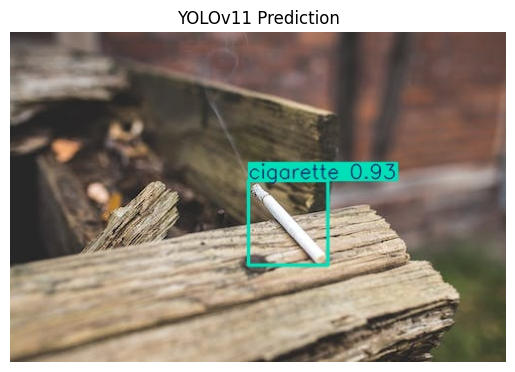

In [ ]:
# 예측할 이미지 경로
img_path = "/content/cigarette_normal_img_hod_005335.jpg"  # 여기에 테스트할 이미지 경로 지정

# 예측 수행
results = model(img_path)

# 결과 이미지 저장
results[0].save(filename="/content/pred_result.jpg")

# 이미지 시각화
img = cv2.imread("/content/pred_result.jpg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("YOLOv11 Prediction")
plt.axis("off")
plt.show()



image 1/1 /content/cigarette_normal_img_hod_005335.jpg: 448x640 1 cigarette, 27.4ms
Speed: 3.2ms preprocess, 27.4ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)


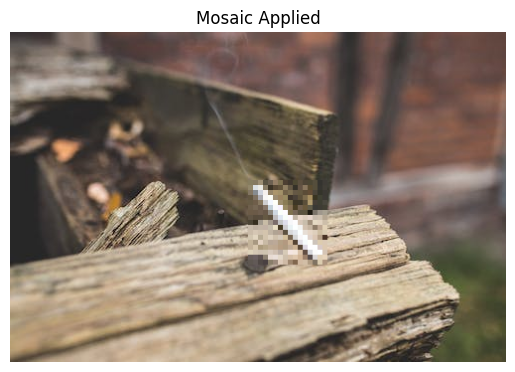

In [ ]:
# 2️⃣ 이미지 로드
img_path = "/content/cigarette_normal_img_hod_005335.jpg"
img = cv2.imread(img_path)

# 3️⃣ 예측 수행
results = model(img_path)[0]

# 4️⃣ 모자이크 함수 정의
def mosaic_area(image, x1, y1, x2, y2, ratio=0.2):
    roi = image[y1:y2, x1:x2]
    h, w = roi.shape[:2]
    small = cv2.resize(roi, (max(1, int(w * ratio)), max(1, int(h * ratio))), interpolation=cv2.INTER_LINEAR)
    mosaic = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
    image[y1:y2, x1:x2] = mosaic
    return image

# 5️⃣ 박스마다 모자이크 적용
for box in results.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    img = mosaic_area(img, x1, y1, x2, y2)

# 6️⃣ 결과 저장 및 시각화
output_path = "/content/mosaic_result.jpg"
cv2.imwrite(output_path, img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Mosaic Applied")
plt.axis("off")
plt.show()